# Swallowing Sound Analysis: Pre-Post DTW Alignment & Feature Extraction

## Workflow

1. **Load and explore** the SPL data
2. **DTW alignment** between pre-swallow and post-swallow segments within each patient
3. **Extract ALL features** (Tsfresh) from:
   - Pre-swallow signals
   - Post-swallow signals
4. **ANOVA repeted measures** for feature selection and analysis


## 1. Setup and Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

# DTW libraries
from dtaidistance import dtw
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy import stats

# Feature extraction
from tsfresh import extract_features
from tsfresh.feature_extraction import ComprehensiveFCParameters, MinimalFCParameters, EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute

# Clustering and ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, confusion_matrix

# Anova and stats
from itertools import product
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind

try:
    import pingouin as pg
except ImportError:
    !pip install pingouin
    import pingouin as pg
    
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries loaded successfully!")

All libraries loaded successfully!


### 1.1. Data Loading and Exploration

In [3]:
# Load the data
DATA_PATH = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\SPL_data.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head(10)

Dataset shape: (41584, 8)

Column names: ['audio_file', 'segment_type', 'frequency_hz', 'spl_db', 'detected_swallows', 'expected_swallows', 'group', 'volume_ml']


,audio_file,segment_type,frequency_hz,spl_db,detected_swallows,expected_swallows,group,volume_ml
0,GC-F10-10ml.wav,pre_swallow,21.533203,31.061598,2,2,Control,10.0
1,GC-F10-10ml.wav,pre_swallow,32.299805,38.162357,2,2,Control,10.0
2,GC-F10-10ml.wav,pre_swallow,43.066406,40.669239,2,2,Control,10.0
3,GC-F10-10ml.wav,pre_swallow,53.833008,41.282619,2,2,Control,10.0
4,GC-F10-10ml.wav,pre_swallow,64.599609,39.009421,2,2,Control,10.0
5,GC-F10-10ml.wav,pre_swallow,75.366211,34.653134,2,2,Control,10.0
6,GC-F10-10ml.wav,pre_swallow,86.132812,30.625066,2,2,Control,10.0
7,GC-F10-10ml.wav,pre_swallow,96.899414,28.764773,2,2,Control,10.0
8,GC-F10-10ml.wav,pre_swallow,107.666016,27.122089,2,2,Control,10.0
9,GC-F10-10ml.wav,pre_swallow,118.432617,24.627552,2,2,Control,10.0


In [4]:
# Basic data info
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nTotal records: {len(df):,}")
print(f"\nUnique audio files: {df['audio_file'].nunique()}")
print(f"\nSegment types:\n{df['segment_type'].value_counts()}")
print(f"\nGroups:\n{df['group'].value_counts()}")
print(f"\nVolumes (ml):\n{df['volume_ml'].value_counts().sort_index()}")

DATA OVERVIEW

Total records: 41,584

Unique audio files: 107

Segment types:
segment_type
pre_swallow     20792
post_swallow    20792
Name: count, dtype: int64

Groups:
group
Control    26496
Study      15088
Name: count, dtype: int64

Volumes (ml):
volume_ml
3.0     8464
5.0     8096
10.0    9200
20.0    8096
50.0    6624
Name: count, dtype: int64


### 1.2. Data Preparation

In [5]:
def prepare_time_series_data(df):
    ts_dict = {}
    metadata_list = []
    
    sample_groups = df.groupby(['audio_file', 'segment_type'])
    
    for (audio_file, segment_type), group_df in sample_groups:
        group_df = group_df.sort_values('frequency_hz')
        
        sample_id = f"{audio_file}_{segment_type}"
        spl_values = group_df['spl_db'].values
        
        ts_dict[sample_id] = spl_values
        
        metadata_list.append({
            'sample_id': sample_id,
            'audio_file': audio_file,
            'segment_type': segment_type,
            'group': group_df['group'].iloc[0],
            'volume_ml': group_df['volume_ml'].iloc[0],
            'detected_swallows': group_df['detected_swallows'].iloc[0],
            'expected_swallows': group_df['expected_swallows'].iloc[0]
        })
    
    metadata_df = pd.DataFrame(metadata_list)
    
    freq_bins = df[df['audio_file'] == df['audio_file'].iloc[0]]
    freq_bins = freq_bins[freq_bins['segment_type'] == freq_bins['segment_type'].iloc[0]]
    freq_values = freq_bins.sort_values('frequency_hz')['frequency_hz'].values
    
    return ts_dict, metadata_df, freq_values

ts_dict, metadata_df, freq_values = prepare_time_series_data(df)

print(f"Number of time series samples: {len(ts_dict)}")
print(f"Length of each time series: {len(list(ts_dict.values())[0])} frequency bins")
print(f"\nSample distribution by group and segment:")
print(metadata_df.groupby(['group', 'segment_type']).size().unstack(fill_value=0))

Number of time series samples: 214
Length of each time series: 184 frequency bins

Sample distribution by group and segment:
segment_type  post_swallow  pre_swallow
group                                  
Control                 70           70
Study                   37           37


## 2. DTW Alignment: Pre vs Post Swallow

In [6]:
def compute_pre_post_dtw_alignment(ts_dict, metadata_df):
    audio_files = metadata_df['audio_file'].unique()
    
    results = []
    aligned_pairs = {}
    
    for audio_file in audio_files:
        pre_id = f"{audio_file}_pre_swallow"
        post_id = f"{audio_file}_post_swallow"
        
        if pre_id not in ts_dict or post_id not in ts_dict:
            continue
        
        pre_signal = np.array(ts_dict[pre_id], dtype=np.float64)
        post_signal = np.array(ts_dict[post_id], dtype=np.float64)
        
        distance = dtw.distance(pre_signal, post_signal)
        path = dtw.warping_path(pre_signal, post_signal)
        
        meta = metadata_df[metadata_df['audio_file'] == audio_file].iloc[0]
        
        results.append({
            'audio_file': audio_file,
            'group': meta['group'],
            'volume_ml': meta['volume_ml'],
            'dtw_distance': distance,
            'detected_swallows': meta['detected_swallows'],
            'expected_swallows': meta['expected_swallows']
        })
        
        aligned_pairs[audio_file] = {
            'pre': pre_signal,
            'post': post_signal,
            'path': path,
            'distance': distance
        }
    
    return pd.DataFrame(results), aligned_pairs

print("Computing DTW alignments...")
alignment_results, aligned_pairs = compute_pre_post_dtw_alignment(ts_dict, metadata_df)

print(f"Computed alignments for {len(alignment_results)} audio files")
print(f"\nDTW Distance Statistics by Group:")
print(alignment_results.groupby('group')['dtw_distance'].describe())

Computing DTW alignments...
Computed alignments for 107 audio files

DTW Distance Statistics by Group:
         count       mean        std        min        25%       50%  \
group                                                                  
Control   70.0  27.298171   7.342980  16.848383  22.203290  25.47530   
Study     37.0  37.344084  26.409452  18.104250  22.458021  28.10811   

               75%         max  
group                           
Control  30.379512   51.022696  
Study    34.242845  129.012319  


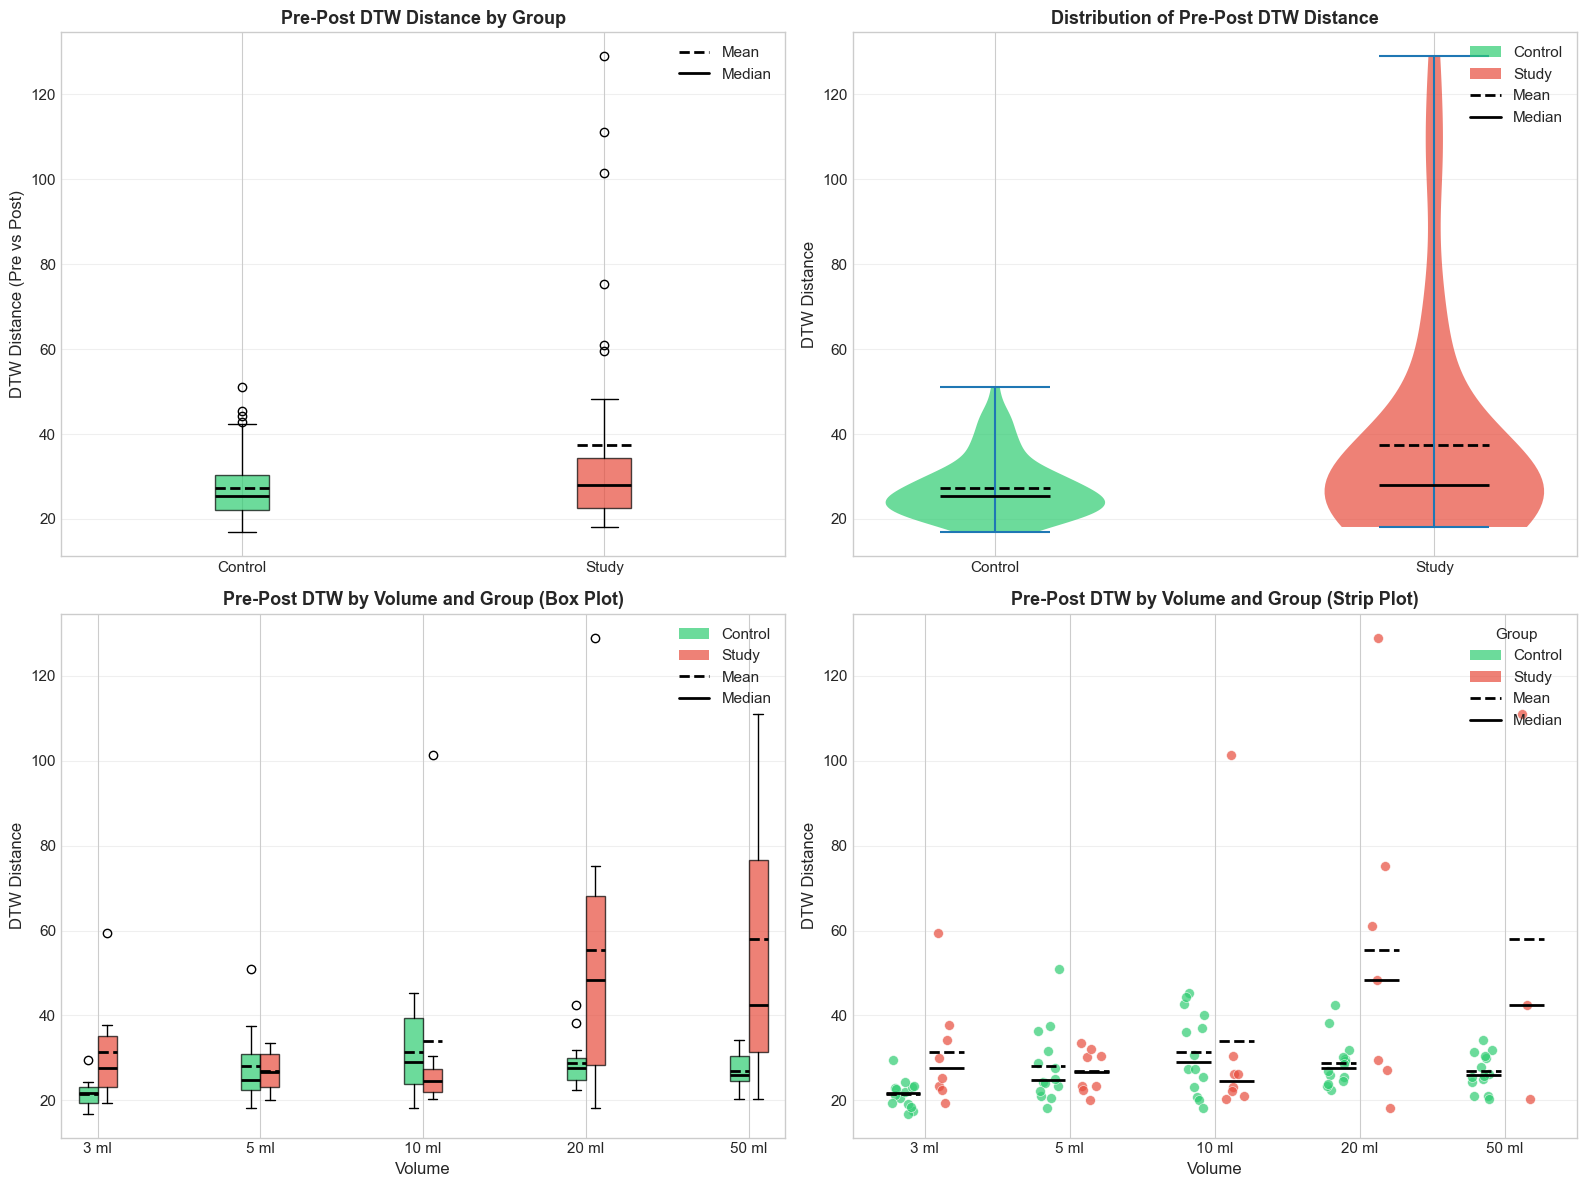


DTW DISTANCE STATISTICS BY GROUP

Control:
  n=70, mean=27.30, std=7.34, median=25.48
  min=16.85, max=51.02
  Q1=22.20, Q3=30.38

Study:
  n=37, mean=37.34, std=26.41, median=28.11
  min=18.10, max=129.01
  Q1=22.46, Q3=34.24

DTW DISTANCE STATISTICS BY VOLUME AND GROUP

--- Volume: 3 ml ---
  Control: n=14, mean=21.53, std=3.28, median=21.71
  Study: n=8, mean=31.48, std=12.91, median=27.62

--- Volume: 5 ml ---
  Control: n=14, mean=28.00, std=8.76, median=24.77
  Study: n=8, mean=26.94, std=5.17, median=26.80

--- Volume: 10 ml ---
  Control: n=14, mean=31.37, std=9.50, median=29.01
  Study: n=8, mean=33.91, std=27.49, median=24.66

--- Volume: 20 ml ---
  Control: n=14, mean=28.79, std=5.72, median=27.70
  Study: n=7, mean=55.48, std=38.19, median=48.26

--- Volume: 50 ml ---
  Control: n=14, mean=26.81, std=4.36, median=26.00
  Study: n=3, mean=57.92, std=47.34, median=42.42


In [7]:
# COMPLETE VERSION - All 4 plots with MEAN (dashed) and MEDIAN (solid)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

groups = list(alignment_results['group'].unique())
colors = {'Control': '#2ecc71', 'Study': '#e74c3c', 'Dysphagia': '#e74c3c'}

# Define correct volume order
volume_order = [3, 5, 10, 20, 50]
valid_volumes = [v for v in volume_order if v in alignment_results['volume_ml'].unique()]

# ===========================================
# Plot 1: Box plot by Group (TOP LEFT)
# ===========================================
ax = axes[0, 0]
box_data = [alignment_results[alignment_results['group'] == g]['dtw_distance'].values for g in groups]
bp = ax.boxplot(box_data, labels=groups, patch_artist=True, 
                showmeans=True, meanline=True,
                meanprops=dict(color='black', linewidth=2, linestyle='--'),
                medianprops=dict(color='black', linewidth=2, linestyle='-'))  # Solid line for median

for patch, g in zip(bp['boxes'], groups):
    patch.set_facecolor(colors.get(g, 'gray'))
    patch.set_alpha(0.7)

ax.set_ylabel('DTW Distance (Pre vs Post)', fontsize=12)
ax.set_title('Pre-Post DTW Distance by Group', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Legend
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
ax.legend(handles=[mean_line, median_line], loc='upper right')

# ===========================================
# Plot 2: Violin plot by Group (TOP RIGHT)
# ===========================================
ax = axes[0, 1]
parts = ax.violinplot([alignment_results[alignment_results['group'] == g]['dtw_distance'].values for g in groups],
                      positions=range(len(groups)), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors.get(groups[i], 'gray'))
    pc.set_alpha(0.7)

# Mean = dashed, Median = solid
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2)
parts['cmeans'].set_linestyle('--')

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cmedians'].set_linestyle('-')

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.set_title('Distribution of Pre-Post DTW Distance', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Legend
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
group_patches = [mpatches.Patch(facecolor=colors.get(g), alpha=0.7, label=g) for g in groups]
ax.legend(handles=group_patches + [mean_line, median_line], loc='upper right')

# ===========================================
# Plot 3: Boxplot by Volume and Group (BOTTOM LEFT)
# ===========================================
ax = axes[1, 0]

positions = []
box_data = []
box_colors = []

width = 0.35
n_groups = len(groups)

for i, vol in enumerate(valid_volumes):
    for j, g in enumerate(groups):
        subset = alignment_results[
            (alignment_results['volume_ml'] == vol) & 
            (alignment_results['group'] == g)
        ]['dtw_distance'].values
        
        if len(subset) > 0:
            box_data.append(subset)
            pos = i * (n_groups + 1) + j * width
            positions.append(pos)
            box_colors.append(colors.get(g, 'gray'))

bp = ax.boxplot(box_data, positions=positions, widths=width, patch_artist=True, 
                showmeans=True, meanline=True,
                meanprops=dict(color='black', linewidth=2, linestyle='--'),
                medianprops=dict(color='black', linewidth=2, linestyle='-'))  # Solid line for median

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

tick_positions = [i * (n_groups + 1) + width * (n_groups - 1) / 2 for i in range(len(valid_volumes))]
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'{v} ml' for v in valid_volumes])

ax.set_xlabel('Volume', fontsize=12)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.set_title('Pre-Post DTW by Volume and Group (Box Plot)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Legend
legend_patches = [mpatches.Patch(facecolor=colors.get(g), alpha=0.7, label=g) for g in groups]
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
ax.legend(handles=legend_patches + [mean_line, median_line], loc='upper right')

# ===========================================
# Plot 4: Strip plot by Volume and Group (BOTTOM RIGHT)
# ===========================================
ax = axes[1, 1]

np.random.seed(42)

for i, vol in enumerate(valid_volumes):
    for j, g in enumerate(groups):
        subset = alignment_results[
            (alignment_results['volume_ml'] == vol) & 
            (alignment_results['group'] == g)
        ]['dtw_distance'].values
        
        if len(subset) > 0:
            base_x = i + (j - 0.5) * 0.3
            jitter = np.random.uniform(-0.08, 0.08, len(subset))
            x_values = base_x + jitter
            
            ax.scatter(
                x_values, 
                subset,
                c=colors.get(g, 'gray'),
                alpha=0.7,
                s=50,
                edgecolors='white',
                linewidths=0.5,
                label=g if i == 0 else None
            )
            
            # Add mean line (dashed)
            mean_val = np.mean(subset)
            ax.hlines(mean_val, base_x - 0.12, base_x + 0.12, colors='black', 
                      linewidths=2, linestyles='--')
            
            # Add median line (solid)
            median_val = np.median(subset)
            ax.hlines(median_val, base_x - 0.12, base_x + 0.12, colors='black', 
                      linewidths=2, linestyles='-')

ax.set_xticks(range(len(valid_volumes)))
ax.set_xticklabels([f'{v} ml' for v in valid_volumes])

ax.set_xlabel('Volume', fontsize=12)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.set_title('Pre-Post DTW by Volume and Group (Strip Plot)', fontsize=13, fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(facecolor=colors.get(g), alpha=0.7, label=g) for g in groups]
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
ax.legend(handles=legend_patches + [mean_line, median_line], title='Group', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pre_post_dtw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ===========================================
# Print Statistics
# ===========================================
print("\n" + "="*70)
print("DTW DISTANCE STATISTICS BY GROUP")
print("="*70)

for g in groups:
    subset = alignment_results[alignment_results['group'] == g]['dtw_distance']
    print(f"\n{g}:")
    print(f"  n={len(subset)}, mean={subset.mean():.2f}, std={subset.std():.2f}, median={subset.median():.2f}")
    print(f"  min={subset.min():.2f}, max={subset.max():.2f}")
    print(f"  Q1={subset.quantile(0.25):.2f}, Q3={subset.quantile(0.75):.2f}")

print("\n" + "="*70)
print("DTW DISTANCE STATISTICS BY VOLUME AND GROUP")
print("="*70)

for vol in valid_volumes:
    print(f"\n--- Volume: {vol} ml ---")
    for g in groups:
        subset = alignment_results[
            (alignment_results['volume_ml'] == vol) & 
            (alignment_results['group'] == g)
        ]['dtw_distance']
        
        if len(subset) > 0:
            print(f"  {g}: n={len(subset)}, mean={subset.mean():.2f}, "
                  f"std={subset.std():.2f}, median={subset.median():.2f}")
        else:
            print(f"  {g}: No data")

## 3. Feature Extraction 

In [8]:
def extract_basic_features(aligned_pairs, alignment_results):
    feature_records = []
    
    for audio_file in aligned_pairs.keys():
        data = aligned_pairs[audio_file]
        meta = alignment_results[alignment_results['audio_file'] == audio_file].iloc[0]
        
        pre = data['pre']
        post = data['post']
                
        features = {'audio_file': audio_file}
        
        # Pre-swallow features
        features['pre_mean'] = np.mean(pre)
        features['pre_std'] = np.std(pre)
        features['pre_max'] = np.max(pre)
        features['pre_min'] = np.min(pre)
        features['pre_range'] = np.ptp(pre)
        features['pre_skew'] = stats.skew(pre)
        features['pre_kurtosis'] = stats.kurtosis(pre)
        features['pre_energy'] = np.sum(pre**2)
        features['pre_rms'] = np.sqrt(np.mean(pre**2))
        features['pre_median'] = np.median(pre)
        features['pre_iqr'] = np.percentile(pre, 75) - np.percentile(pre, 25)
        
        # Post-swallow features
        features['post_mean'] = np.mean(post)
        features['post_std'] = np.std(post)
        features['post_max'] = np.max(post)
        features['post_min'] = np.min(post)
        features['post_range'] = np.ptp(post)
        features['post_skew'] = stats.skew(post)
        features['post_kurtosis'] = stats.kurtosis(post)
        features['post_energy'] = np.sum(post**2)
        features['post_rms'] = np.sqrt(np.mean(post**2))
        features['post_median'] = np.median(post)
        features['post_iqr'] = np.percentile(post, 75) - np.percentile(post, 25)
              
        # Ratios
        features['energy_ratio'] = features['post_energy'] / (features['pre_energy'] + 1e-10)
        features['mean_ratio'] = features['post_mean'] / (features['pre_mean'] + 1e-10)
        features['pre_post_correlation'] = np.corrcoef(pre, post)[0, 1]
        features['dtw_distance'] = data['distance']
        
        # Metadata
        features['group'] = meta['group']
        features['volume_ml'] = meta['volume_ml']
        
        feature_records.append(features)
    
    return pd.DataFrame(feature_records)

basic_features_df = extract_basic_features(aligned_pairs, alignment_results)
print(f"Basic features shape: {basic_features_df.shape}")

Basic features shape: (107, 29)


In [9]:
# Prepare tsfresh data
def prepare_tsfresh_data(aligned_pairs):
    records = []
    for audio_file, data in aligned_pairs.items():
        pre = data['pre']
        post = data['post']
               
        for t in range(len(pre)):
            records.append({
                'id': audio_file,
                'time': t,
                'pre_spl': pre[t],
                'post_spl': post[t],
            })
    return pd.DataFrame(records)

tsfresh_data = prepare_tsfresh_data(aligned_pairs)
print(f"tsfresh data shape: {tsfresh_data.shape}")

tsfresh data shape: (20792, 4)


In [10]:
# Extract COMPREHENSIVE features from PRE-SWALLOW
print("="*60)
print("Extracting COMPREHENSIVE features from PRE-SWALLOW signal...")
print("This will take several minutes...")
print("="*60)

pre_features = extract_features(
    tsfresh_data[['id', 'time', 'pre_spl']],
    column_id='id', column_sort='time', column_value='pre_spl',
    default_fc_parameters=ComprehensiveFCParameters(),
    n_jobs=0, disable_progressbar=False
)

impute(pre_features)
zero_var = pre_features.var() == 0
pre_features_clean = pre_features.loc[:, ~zero_var]
pre_features_clean.columns = ['pre_' + c for c in pre_features_clean.columns]

print(f"\nPre-swallow features: {pre_features_clean.shape[1]}")

Extracting COMPREHENSIVE features from PRE-SWALLOW signal...
This will take several minutes...


Feature Extraction: 100%|██████████| 107/107 [00:13<00:00,  8.01it/s]



Pre-swallow features: 737


In [11]:
# Extract COMPREHENSIVE features from POST-SWALLOW
print("="*60)
print("Extracting COMPREHENSIVE features from POST-SWALLOW signal...")
print("="*60)

post_features = extract_features(
    tsfresh_data[['id', 'time', 'post_spl']],
    column_id='id', column_sort='time', column_value='post_spl',
    default_fc_parameters=ComprehensiveFCParameters(),
    n_jobs=0, disable_progressbar=False
)

impute(post_features)
zero_var = post_features.var() == 0
post_features_clean = post_features.loc[:, ~zero_var]
post_features_clean.columns = ['post_' + c for c in post_features_clean.columns]

print(f"\nPost-swallow features: {post_features_clean.shape[1]}")

Extracting COMPREHENSIVE features from POST-SWALLOW signal...


Feature Extraction: 100%|██████████| 107/107 [00:13<00:00,  8.00it/s]



Post-swallow features: 736


In [12]:
# Combine all features
print("\n" + "="*60)
print("COMBINING ALL FEATURES")
print("="*60)

all_tsfresh = pd.concat([pre_features_clean, post_features_clean], axis=1)
all_tsfresh['audio_file'] = all_tsfresh.index

final_features_df = basic_features_df.merge(all_tsfresh, on='audio_file', how='inner')

metadata_cols = ['audio_file', 'group', 'volume_ml']
feature_cols = [c for c in final_features_df.columns if c not in metadata_cols]

print(f"\nFinal features shape: {final_features_df.shape}")
print(f"\nFeature breakdown:")
print(f"  - Basic: {basic_features_df.shape[1] - 3}")
print(f"  - Pre tsfresh: {pre_features_clean.shape[1]}")
print(f"  - Post tsfresh: {post_features_clean.shape[1]}")
print(f"  - TOTAL: {len(feature_cols)}")

final_features_df.to_csv('extracted_features_comprehensive.csv', index=False)
print("\nSaved to 'extracted_features_comprehensive.csv'")


COMBINING ALL FEATURES

Final features shape: (107, 1502)

Feature breakdown:
  - Basic: 26
  - Pre tsfresh: 737
  - Post tsfresh: 736
  - TOTAL: 1499

Saved to 'extracted_features_comprehensive.csv'


### 3.1. Data Preparation for Analysis

In [13]:
X = final_features_df[feature_cols].values
y = final_features_df['group'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix: {X_scaled.shape}")
print(f"Classes: {le.classes_}")
print(f"Distribution: {dict(zip(le.classes_, np.bincount(y_encoded)))}")

Feature matrix: (107, 1499)
Classes: ['Control' 'Study']
Distribution: {'Control': 70, 'Study': 37}


## 4. ANOVA mixed repeted measures

Anova medidas repetidas mistas (relacionar antes-pos com o grupo e para cada volume), selecionar os valores significativos (p<5%)

Output da tabela --> nome da variavel, em cada coluna tem a media do pre e desvio padrao, media do pos e desvio padrao, tamanho n da amostra e valor p (organizar pelo valor p ascendente)




In [14]:
# Load the extracted features
df = pd.read_csv(r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\Data\extracted_features_comprehensive.csv")

print(f"Data shape: {df.shape}")
print(f"Groups: {df['group'].unique()}")

# Check for NaN volumes BEFORE fixing
print(f"\nRows with NaN volume BEFORE fix: {df['volume_ml'].isna().sum()}")
print("Files with NaN volume:")
print(df[df['volume_ml'].isna()]['audio_file'].tolist())

def extract_volume(filename):
    """
    Extract volume from filename using case-insensitive regex.
    Handles: 10ml, 10Ml, 10ML, etc.
    """
    match = re.search(r'(\d+)ml', filename, re.IGNORECASE)  # Case insensitive!
    if match:
        return float(match.group(1))
    return np.nan

# Re-extract volumes for ALL rows (to ensure consistency)
df['volume_ml'] = df['audio_file'].apply(extract_volume)

# Verify the fix
print(f"\nRows with NaN volume AFTER fix: {df['volume_ml'].isna().sum()}")

# Check if any still have NaN
if df['volume_ml'].isna().sum() > 0:
    print("Files still with NaN volume:")
    print(df[df['volume_ml'].isna()]['audio_file'].tolist())
else:
    print("✓ All volumes extracted successfully!")

print(f"\nVolumes: {sorted(df['volume_ml'].unique())}")
print(f"Samples per volume:\n{df['volume_ml'].value_counts().sort_index()}")

Data shape: (107, 1502)
Groups: ['Control' 'Study']

Rows with NaN volume BEFORE fix: 3
Files with NaN volume:
['GE-M3-10Ml.wav', 'GE-M7-3ml.wav', 'GE-M7-5ml.wav']

Rows with NaN volume AFTER fix: 0
✓ All volumes extracted successfully!

Volumes: [3.0, 5.0, 10.0, 20.0, 50.0]
Samples per volume:
volume_ml
3.0     23
5.0     23
10.0    23
20.0    21
50.0    17
Name: count, dtype: int64


In [15]:
# Get all column names
all_cols = df.columns.tolist()
meta_cols = ['audio_file', 'group', 'volume_ml']

# Find features that have BOTH pre_ and post_ versions
# Basic features: pre_mean <-> post_mean
# tsfresh features: pre_pre_spl__* <-> post_post_spl__*

def find_feature_pairs(columns):
    """
    Find matching pre/post feature pairs.
    """
    pairs = []
    
    # Basic features (pre_X and post_X)
    basic_pre = [c for c in columns if c.startswith('pre_') and not c.startswith('pre_pre_')]
    for pre_col in basic_pre:
        # Get the feature name after 'pre_'
        feature_name = pre_col[4:]  # Remove 'pre_'
        post_col = f'post_{feature_name}'
        
        if post_col in columns:
            pairs.append({
                'feature_name': feature_name,
                'pre_col': pre_col,
                'post_col': post_col
            })
    
    # tsfresh features (pre_pre_spl__X and post_post_spl__X)
    tsfresh_pre = [c for c in columns if c.startswith('pre_pre_spl__')]
    for pre_col in tsfresh_pre:
        # Get the feature name after 'pre_pre_spl__'
        feature_name = pre_col[13:]  # Remove 'pre_pre_spl__'
        post_col = f'post_post_spl__{feature_name}'
        
        if post_col in columns:
            pairs.append({
                'feature_name': f'tsfresh_{feature_name}',
                'pre_col': pre_col,
                'post_col': post_col
            })
    
    return pairs

feature_pairs = find_feature_pairs(all_cols)
print(f"Found {len(feature_pairs)} matching pre/post feature pairs")
print(f"\nFirst 10 pairs:")
for p in feature_pairs[:10]:
    print(f"  {p['feature_name']}: {p['pre_col']} <-> {p['post_col']}")

Found 746 matching pre/post feature pairs

First 10 pairs:
  mean: pre_mean <-> post_mean
  std: pre_std <-> post_std
  max: pre_max <-> post_max
  min: pre_min <-> post_min
  range: pre_range <-> post_range
  skew: pre_skew <-> post_skew
  kurtosis: pre_kurtosis <-> post_kurtosis
  energy: pre_energy <-> post_energy
  rms: pre_rms <-> post_rms
  median: pre_median <-> post_median


In [16]:
def reshape_to_long(df, feature_pairs):
    """
    Reshape data from wide to long format for mixed ANOVA.
    Each subject will have 2 rows (Pre and Post).
    """
    
    long_records = []
    
    for idx, row in df.iterrows():
        # Pre condition
        pre_record = {
            'subject': row['audio_file'],
            'condition': 'Pre',
            'group': row['group'],
            'volume_ml': row['volume_ml']
        }
        for pair in feature_pairs:
            pre_record[pair['feature_name']] = row[pair['pre_col']]
        long_records.append(pre_record)
        
        # Post condition
        post_record = {
            'subject': row['audio_file'],
            'condition': 'Post',
            'group': row['group'],
            'volume_ml': row['volume_ml']
        }
        for pair in feature_pairs:
            post_record[pair['feature_name']] = row[pair['post_col']]
        long_records.append(post_record)
    
    return pd.DataFrame(long_records)

# Reshape data
long_df = reshape_to_long(df, feature_pairs)
print(f"Long format shape: {long_df.shape}")
print(f"Rows per subject: {long_df.groupby('subject').size().unique()}")
print(f"\nSample of long format:")
print(long_df.head(4))
long_df.to_csv("features_ANOVA.csv")

Long format shape: (214, 750)
Rows per subject: [2]

Sample of long format:
           subject condition    group  volume_ml       mean        std  \
0  GC-F10-10ml.wav       Pre  Control       10.0 -11.025078  22.135104   
1  GC-F10-10ml.wav      Post  Control       10.0  -9.396603  22.291735   
2  GC-F10-20ml.wav       Pre  Control       20.0 -19.286976  20.156325   
3  GC-F10-20ml.wav      Post  Control       20.0 -13.689143  22.058615   

         max        min       range      skew  ...  \
0  41.282619 -83.230873  124.513493  0.327898  ...   
1  41.912781 -86.092484  128.005264  0.005217  ...   
2  32.886445 -95.660832  128.547277  0.375144  ...   
3  33.445872 -96.555085  130.000957 -0.150415  ...   

   tsfresh_fourier_entropy__bins_3  tsfresh_fourier_entropy__bins_5  \
0                         0.059432                         0.059432   
1                         0.059432                         0.118748   
2                         0.059432                         0.118748  

Filtrar pelo grupo, testar sem a interação e a variavel de grupo é a mais significativa, todas as features que distingam os grupos é valorizavel ---> colocar os volumes na interação intra grupo

Pressupostos: 
- Normalidade (Shapiro-Wilk) --> não paramétrico (Mann-Whitney)
- Esfericidade (Mauchly)
- Homegeneidade das variaveis (Levene)

H0: µ1 = µ2 = µ3 = … = µk

H1: at least two means are significantly different

Anova 2x2x4:
- Grupo (between): saudável vs. disfagia
- Fase (within): pré vs. pós
- Volume (within): 3, 5, 10, 20 ml

#### For each volume:

1. ASSUMPTION CHECKS
- Shapiro-Wilk  → normality per Group × Condition cell violation of normality --> feito teste nao paramétrico Mann-Whitney

        Mann-Whitney U      → Group effect (between-subjects)

        Wilcoxon signed-rank → Phase effect (within-subjects, 2 levels)

        Mann-Whitney U on ΔPost-Pre → Interaction (Group × Phase)

- Levene's test → variance equality between groups per condition  --> não é rejeitado H0 logo nao exixte diferenças das variancias entre grupos

2. SPHERICITY → not tested (automatically satisfied with 2 within-subjects levels) ''https://www.datanovia.com/en/lessons/mauchlys-test-of-sphericity-in-r/''
- Mauchly’s Test of Sphericity. Only reported for variables or effects with >2 levels because sphericity necessarily holds for effects with only 2 levels. 

3. MIXED ANOVA — via pg.mixed_anova package --> https://www.graphpad.com/guides/prism/latest/statistics/stat_repeated-measures-and-mixed-mo.htm
- Group main effect        (between-subjects: Control vs Study)
- Condition main effect    (within-subjects: Pre vs Post)
- Interaction              (Group × Condition)

4. POST-PROCESSING 
- Bonferroni correction or Benjamini-Hochberg Procedure (FDR)  --> Não está feito ainda esta análise
- Classify effect sizes (ηp²) -->
- Filter at p < 0.05 
- Identify features significant across ≥2 volumes

### Correção de Bonferroni
--> https://www.geeksforgeeks.org/r-language/bonferroni-test/
.  um método de correção de multiplos testes que ajusta o nivel de significancia para contabilizar o numero de comparações, divide o nivel de significancia original pelo numero de testes, sendo mais restrito para testes individuais.


### Correção de Benjamini-Hochberg
--> https://www.geeksforgeeks.org/data-science/benjamini-hochberg-procedure/
. Ao contrario do teste de Bonferroni, que tenta eliminar falsos positivos, este método tenta controlar o False Descovery Rate (FDR), que é a proporção de falsos positivos nos resultados que sao considerados significativos. Teste menos conservador.


In [17]:
df = pd.read_csv(r"C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis\features_ANOVA.csv", index_col=0)
print(f'Original dataset: {df.shape[0]} rows × {df.shape[1]} columns')

# Extract base_subject (subject identity across volumes)
df['base_subject'] = df['subject'].str.extract(r'(G[CE][-_][A-Z]\d+)')
df['base_subject'] = df['base_subject'].str.replace('_', '-')

# Remove 50ml (insufficient sample in Study group)
df = df[df['volume_ml'] != 50.0].copy()
print(f'After removing 50ml: {df.shape[0]} rows')

# Verify structure
print(f'\nSubjects per group:')
for g in sorted(df['group'].unique()):
    n = df[df['group'] == g]['base_subject'].nunique()
    print(f'  {g}: {n} subjects')

print(f'\nGroup × Condition × Volume counts:')
counts = df.groupby(['group', 'condition', 'volume_ml']).size().unstack(fill_value=0)
display(counts)

# Define feature columns (exclude metadata)
meta_cols = ['subject', 'condition', 'group', 'volume_ml', 'base_subject']
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f'\nTotal initial features: {len(feature_cols)}')

Original dataset: 214 rows × 750 columns
After removing 50ml: 180 rows

Subjects per group:
  Control: 14 subjects
  Study: 9 subjects

Group × Condition × Volume counts:


volume_ml          3.0   5.0   10.0  20.0
group   condition                        
Control Post         14    14    14    14
        Pre          14    14    14    14
Study   Post          9     9     9     7
        Pre           9     9     9     7


Total initial features: 746


## Removal of Constant / Near-Constant Features

Features where >95% of values are identical are removed. These produce unstable F-ratios, violate normality assumptions, and have no clinical discriminative value.

In [18]:
CONST_THRESHOLD = 0.95  # Remove if >95% of values are identical

features_to_remove = []
removal_reasons = []

for col in feature_cols:
    series = df[col]
    
    # Zero variance
    if series.std() == 0:
        features_to_remove.append(col)
        removal_reasons.append('zero variance')
        continue
    
    # Near-constant: most frequent value appears in >95% of rows
    most_common_pct = series.value_counts(normalize=True).iloc[0]
    if most_common_pct > CONST_THRESHOLD:
        features_to_remove.append(col)
        removal_reasons.append(f'dominant value in {most_common_pct:.1%} of cases')
        continue

print(f'Features removed ({len(features_to_remove)}):')
removed_df = pd.DataFrame({'feature': features_to_remove, 'reason': removal_reasons})
display(removed_df)

# Apply removal
feature_cols = [c for c in feature_cols if c not in features_to_remove]
print(f'\nRemaining features for analysis: {len(feature_cols)}')

Features removed (12):


,feature,reason
0,tsfresh_has_duplicate_max,dominant value in 98.9% of cases
1,tsfresh_has_duplicate_min,dominant value in 98.9% of cases
2,tsfresh_has_duplicate,dominant value in 98.9% of cases
3,tsfresh_first_location_of_minimum,dominant value in 97.2% of cases
4,tsfresh_percentage_of_reoccurring_values_to_al...,dominant value in 98.9% of cases
5,tsfresh_percentage_of_reoccurring_datapoints_t...,dominant value in 98.9% of cases
6,tsfresh_sum_of_reoccurring_values,dominant value in 98.9% of cases
7,tsfresh_sum_of_reoccurring_data_points,dominant value in 98.9% of cases
8,tsfresh_ratio_value_number_to_time_series_length,dominant value in 98.9% of cases
9,tsfresh_autocorrelation__lag_0,dominant value in 95.6% of cases



Remaining features for analysis: 734


### Normalcy test (Shapiro-Wilk) and homogeneity test (Levene)

In [19]:
volumes = sorted(df['volume_ml'].unique())
groups = sorted(df['group'].unique())
conditions = sorted(df['condition'].unique())
assumption_results = []

non_normal_features = {}  
normal_features = {}      

for vol in volumes:
    df_vol = df[df['volume_ml'] == vol]
    norm_fail = 0
    lev_fail = 0
    total_norm = 0
    total_lev = 0
    failed_feats = set()
    tested_feats = set()

    for feat in feature_cols:
        if df_vol[feat].std() == 0:
            continue

        feat_failed = False
        for g in groups:
            for cond in conditions:
                data = df_vol[(df_vol['group'] == g) & (df_vol['condition'] == cond)][feat].dropna()
                if len(data) >= 3:
                    stat, p = stats.shapiro(data)
                    total_norm += 1
                    tested_feats.add(feat)
                    if p < 0.05:
                        norm_fail += 1
                        feat_failed = True

        if feat_failed:
            failed_feats.add(feat)

        for cond in conditions:
            groups_data = [
                df_vol[(df_vol['group'] == g) & (df_vol['condition'] == cond)][feat].dropna().values
                for g in groups
            ]
            if all(len(d) >= 2 for d in groups_data):
                stat, p = stats.levene(*groups_data)
                total_lev += 1
                if p < 0.05:
                    lev_fail += 1

    non_normal_features[vol] = failed_feats
    normal_features[vol] = tested_feats - failed_feats

    assumption_results.append({
        'Volume (ml)': int(vol),
        'Features tested': len(tested_feats),
        'Normality violations': f'{norm_fail}/{total_norm} ({norm_fail/total_norm:.1%})',
        'Homogeneity violations': f'{lev_fail}/{total_lev} ({lev_fail/total_lev:.1%})',
    })

display(pd.DataFrame(assumption_results).set_index('Volume (ml)'))

# --- KEY OUTPUT ---
# Features that passed normality in ALL volumes → use for repeated measures ANOVA
parametric_features = sorted(set.intersection(*normal_features.values()))

# Features that failed normality in ANY volume → use for non-parametric tests
nonparametric_features = sorted(set.union(*non_normal_features.values()))

print(f"\n✓ Parametric features (passed Shapiro-Wilk in all volumes): {len(parametric_features)}")
print(f"  {parametric_features}")
print(f"\n✗ Non-parametric features (failed in at least one volume): {len(nonparametric_features)}")
print(f"  {nonparametric_features}")

,Features tested,Normality violations,Homogeneity violations
Volume (ml),,,
3,734,699/2936 (23.8%),52/1468 (3.5%)
5,731,310/2924 (10.6%),42/1462 (2.9%)
10,734,1341/2936 (45.7%),25/1468 (1.7%)
20,734,655/2936 (22.3%),111/1468 (7.6%)



✓ Parametric features (passed Shapiro-Wilk in all volumes): 77
  ['mean', 'rms', 'tsfresh_agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"mean"', 'tsfresh_approximate_entropy__m_2__r_0.1', 'tsfresh_ar_coefficient__coeff_7__k_10', 'tsfresh_ar_coefficient__coeff_8__k_10', 'tsfresh_autocorrelation__lag_2', 'tsfresh_autocorrelation__lag_3', 'tsfresh_c3__lag_1', 'tsfresh_c3__lag_2', 'tsfresh_c3__lag_3', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.2', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.6', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.2', 'tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_10__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_10__w_20__

O teste de Levene só é relevante para 

#### Failed normalcy test

In [20]:
# Build a detailed table of normality failures per feature × volume
failure_rows = []

for vol in volumes:
    for feat in sorted(non_normal_features[vol]):
        # Collect which cells failed
        failed_cells = []
        for g in groups:
            for cond in conditions:
                df_vol = df[df['volume_ml'] == vol]
                data = df_vol[(df_vol['group'] == g) & (df_vol['condition'] == cond)][feat].dropna()
                if len(data) >= 3:
                    stat, p = stats.shapiro(data)
                    if p < 0.05:
                        failed_cells.append(f"{g}×{cond} (p={p:.4f})")

        failure_rows.append({
            'Feature': feat,
            'Volume (ml)': int(vol),
            'Failed cells': '; '.join(failed_cells),
            'N failures': len(failed_cells),
        })

df_failures = pd.DataFrame(failure_rows).sort_values(['Feature', 'Volume (ml)'])

# Display as scrollable HTML table
from IPython.display import display, HTML

html = df_failures.to_html(index=False)
display(HTML(f"""
<div style="max-height: 400px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
    {html}
</div>
"""))

print(f"\nTotal entries: {len(df_failures)} (feature × volume combinations that failed normality)")

Feature,Volume (ml),Failed cells,N failures
energy,3,Control×Post (p=0.0315); Control×Pre (p=0.0401),2
energy,10,Control×Post (p=0.0219); Control×Pre (p=0.0120),2
iqr,5,Control×Post (p=0.0065),1
iqr,10,Study×Pre (p=0.0044),1
kurtosis,3,Control×Post (p=0.0301),1
kurtosis,5,Control×Post (p=0.0136),1
kurtosis,10,Study×Pre (p=0.0009),1
kurtosis,20,Control×Post (p=0.0384),1
max,3,Control×Post (p=0.0376),1
median,3,Control×Post (p=0.0117),1



Total entries: 1578 (feature × volume combinations that failed normality)


### Two way ANOVA of variables with normal distribution

For each volume, a two way ANOVA is run on every feature with:
- **Between-subjects factor:** Group (Control vs Study)  
- **Within-subjects factor:** Condition (Pre vs Post)  

This yields 3 effects per feature per volume:
1. **Group** — main effect of group
2. **Condition** — main effect of phase (pre vs post)
3. **Interaction** — Group × Phase interaction (clinically most relevant)

In [21]:
import pingouin as pg

anova_results = []

for vol in volumes:
    df_vol = df[df['volume_ml'] == vol].copy()

    for feat in parametric_features:
        try:
            aov = pg.mixed_anova(
                data=df_vol,
                dv=feat,
                within='condition',
                between='group',
                subject='subject',  
            )
            for _, row in aov.iterrows():
                anova_results.append({
                    'Volume (ml)': int(vol),
                    'Feature': feat,
                    'Source': row['Source'],
                    'F': round(row['F'], 4),
                    'p-value': round(row['p-unc'], 4),
                    'np2': round(row['np2'], 4),  # partial eta-squared
                    'Significant': '✓' if row['p-unc'] < 0.05 else '',
                })
        except Exception as e:
            anova_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'Source': 'ERROR',
                'F': None,
                'p-value': None,
                'np2': None,
                'Significant': str(e),
            })

df_anova = pd.DataFrame(anova_results)

# Scrollable table
from IPython.display import display, HTML

html = df_anova.to_html(index=False)
display(HTML(f"""
<div style="max-height: 500px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
    {html}
</div>
"""))

# Quick summary: only significant results
df_sig = df_anova[df_anova['Significant'] == '✓']
print(f"\nSignificant effects: {len(df_sig)} out of {len(df_anova)} tests")

Volume (ml),Feature,Source,F,p-value,np2,Significant
3,mean,group,0.0059,0.9395,0.0003,
3,mean,condition,0.8490,0.3673,0.0389,
3,mean,Interaction,0.9691,0.3361,0.0441,
3,rms,group,0.7234,0.4046,0.0333,
3,rms,condition,3.0680,0.0944,0.1275,
3,rms,Interaction,1.1914,0.2874,0.0537,
3,"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_50__f_agg_""max""",group,0.5802,0.4547,0.0269,
3,"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_50__f_agg_""max""",condition,1.1786,0.2900,0.0531,
3,"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_50__f_agg_""max""",Interaction,0.8169,0.3764,0.0374,
3,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",group,1.3923,0.2512,0.0622,



Significant effects: 73 out of 924 tests


In [22]:
# Filter only significant results
df_sig = df_anova[df_anova['Significant'] == '✓'].copy()

# Scrollable table
from IPython.display import display, HTML

html = df_sig.to_html(index=False)
display(HTML(f"""
<div style="max-height: 500px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
    {html}
</div>
"""))

# Store the unique feature names for downstream use
sig_features = sorted(df_sig['Feature'].unique())
print(f"\n{len(df_sig)} significant effects across {len(sig_features)} features:")
print(sig_features)

Volume (ml),Feature,Source,F,p-value,np2,Significant
3,tsfresh_approximate_entropy__m_2__r_0.1,Interaction,6.0816,0.0224,0.2246,✓
3,"tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)",condition,8.2355,0.0092,0.2817,✓
3,"tsfresh_cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)",group,5.2331,0.0326,0.1995,✓
3,"tsfresh_cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)",group,5.5855,0.0278,0.2101,✓
3,"tsfresh_cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)",group,4.9127,0.0378,0.1896,✓
3,"tsfresh_cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)",condition,9.5815,0.0055,0.3133,✓
3,"tsfresh_cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)",group,6.3210,0.0202,0.2314,✓
3,"tsfresh_cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",group,6.1544,0.0217,0.2266,✓
3,"tsfresh_cwt_coefficients__coeff_6__w_10__widths_(2, 5, 10, 20)",group,5.7332,0.0261,0.2145,✓
3,"tsfresh_cwt_coefficients__coeff_7__w_10__widths_(2, 5, 10, 20)",group,5.0372,0.0357,0.1935,✓



73 significant effects across 46 features:
['mean', 'rms', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"mean"', 'tsfresh_approximate_entropy__m_2__r_0.1', 'tsfresh_autocorrelation__lag_2', 'tsfresh_autocorrelation__lag_3', 'tsfresh_c3__lag_1', 'tsfresh_c3__lag_2', 'tsfresh_c3__lag_3', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_True__qh_0.4__ql_0.2', 'tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_10__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_10__w_20__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_11__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_13__w_5__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__co

In [23]:
print(df_sig.columns.tolist())

['Volume (ml)', 'Feature', 'Source', 'F', 'p-value', 'np2', 'Significant']


## Post-hoc Tukey

In [26]:
# --- Tukey HSD Post-Hoc ---
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_sig_anova = df_anova[df_anova['Significant'] == '✓'].copy()

tukey_results = []

for _, row in df_sig_anova.iterrows():
    vol, feat, source = row['Volume (ml)'], row['Feature'], row['Source']
    df_vol = df[df['volume_ml'] == vol].dropna(subset=[feat]).copy()

    try:
        if source == 'condition':
            res = pairwise_tukeyhsd(df_vol[feat], df_vol['condition'])
        elif source == 'group':
            res = pairwise_tukeyhsd(df_vol[feat], df_vol['group'])
        elif 'nteraction' in source or '*' in source:
            # Create combined cell label for interaction
            df_vol['cell'] = df_vol['condition'].astype(str) + ' | ' + df_vol['group'].astype(str)
            res = pairwise_tukeyhsd(df_vol[feat], df_vol['cell'])
        else:
            continue

        for i in range(len(res.summary().data) - 1):  # skip header row
            r = res.summary().data[i + 1]
            tukey_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'ANOVA Source': source,
                'Group A': r[0],
                'Group B': r[1],
                'Mean Diff': round(float(r[2]), 4),
                'p-tukey': round(float(r[3]), 4),
                'Lower CI': round(float(r[4]), 4),
                'Upper CI': round(float(r[5]), 4),
                'Reject': r[6],
            })
    except Exception as e:
        print(f"⚠ {feat} ({vol}ml, {source}): {e}")

df_tukey = pd.DataFrame(tukey_results)

df_tukey_sig = df_tukey[df_tukey['Reject'] == True].copy()
df_tukey_sig = df_tukey_sig.sort_values(['Volume (ml)', 'Feature', 'p-tukey'])

print(f"Tukey HSD: {len(df_tukey_sig)} significant comparisons "
      f"out of {len(df_tukey)} total\n")

html = df_tukey_sig.to_html(index=False)
display(HTML(f"""
<div style="max-height: 600px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
    <h3>Significant Post-Hoc Comparisons (Tukey HSD)</h3>
    {html}
</div>
"""))

count_summary = (df_tukey_sig.groupby(['Volume (ml)', 'Feature', 'ANOVA Source'])
                 .size().reset_index(name='# Sig Pairs'))
display(HTML("<h3>Significant pairs per feature (Tukey)</h3>"))
display(HTML(count_summary.to_html(index=False)))

Tukey HSD: 54 significant comparisons out of 123 total



Volume (ml),Feature,ANOVA Source,Group A,Group B,Mean Diff,p-tukey,Lower CI,Upper CI,Reject
3,"tsfresh_cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)",group,Control,Study,5.8449,0.0069,1.6878,10.0020,True
3,"tsfresh_cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)",group,Control,Study,9.8657,0.0095,2.5316,17.1998,True
3,"tsfresh_cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)",group,Control,Study,12.5594,0.0039,4.2583,20.8604,True
3,"tsfresh_cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",group,Control,Study,12.7146,0.0044,4.1693,21.2599,True
3,"tsfresh_cwt_coefficients__coeff_6__w_10__widths_(2, 5, 10, 20)",group,Control,Study,12.5212,0.0060,3.7853,21.2571,True
3,"tsfresh_cwt_coefficients__coeff_7__w_10__widths_(2, 5, 10, 20)",group,Control,Study,12.0012,0.0096,3.0717,20.9307,True
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Interaction,Post | Study,Pre | Study,-7.3437,0.0352,-14.3038,-0.3836,True
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_5",group,Control,Study,9.9513,0.0001,5.1200,14.7826,True
5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Interaction,Post | Control,Post | Study,0.6337,0.0462,0.0078,1.2596,True
5,"tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)",group,Control,Study,9.5244,0.0117,2.2302,16.8185,True


Volume (ml),Feature,ANOVA Source,# Sig Pairs
3,"tsfresh_cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_6__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_7__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Interaction,1
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_5",group,1
5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Interaction,1
5,"tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)",group,1


In [27]:
# --- Post-hoc for mixed 2x2 ANOVA (design-aware) ---
# Tukey HSD is only valid for INDEPENDENT samples, so apply it only where the
# comparison is between-subjects. Use paired t-tests for within-subject contrasts.
#
#   'group'       (between)    -> Tukey HSD
#   'condition'   (within)     -> paired t-test
#   'Interaction'              -> simple effects:
#                                   Pre vs Post @ each group      -> paired t
#                                   Control vs Study @ each phase -> Tukey HSD
#                                 Bonferroni-corrected across the 4-test family

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

df_sig_anova = df_anova[df_anova['Significant'] == '✓'].copy()

posthoc_rows = []

def _paired_prepost(sub, feat):
    """Return aligned Pre/Post arrays for the same subjects."""
    pre  = sub[sub['condition'] == 'Pre' ].set_index('subject')[feat].dropna()
    post = sub[sub['condition'] == 'Post'].set_index('subject')[feat].dropna()
    common = pre.index.intersection(post.index)
    return pre.loc[common].values, post.loc[common].values

for _, r in df_sig_anova.iterrows():
    vol, feat, source = r['Volume (ml)'], r['Feature'], r['Source']
    df_vol = df[df['volume_ml'] == vol].dropna(subset=[feat]).copy()

    try:
        if source == 'group':
            res = pairwise_tukeyhsd(df_vol[feat], df_vol['group'])
            for rr in res.summary().data[1:]:
                posthoc_rows.append({
                    'Volume (ml)': int(vol), 'Feature': feat, 'ANOVA Source': source,
                    'Test': 'Tukey HSD', 'Paired': False,
                    'Contrast': f'{rr[0]} vs {rr[1]}',
                    'Statistic': round(float(rr[2]), 4),
                    'p-value':   round(float(rr[3]), 4),
                    'p-bonf':    round(float(rr[3]), 4),   # no family here
                    'Reject H0': bool(rr[6]),
                })

        elif source == 'condition':
            pre_v, post_v = _paired_prepost(df_vol, feat)
            if len(pre_v) >= 3:
                t, p = ttest_rel(pre_v, post_v)
                posthoc_rows.append({
                    'Volume (ml)': int(vol), 'Feature': feat, 'ANOVA Source': source,
                    'Test': 'Paired t-test', 'Paired': True,
                    'Contrast': 'Pre vs Post',
                    'Statistic': round(float(t), 4),
                    'p-value':   round(float(p), 4),
                    'p-bonf':    round(float(p), 4),       # single test in family
                    'Reject H0': bool(p < 0.05),
                })

        elif 'nteraction' in source or '*' in source:
            family = []

            # Between-group @ each phase (independent -> Tukey)
            for cond in ['Pre', 'Post']:
                sub = df_vol[df_vol['condition'] == cond]
                if sub['group'].nunique() == 2:
                    res = pairwise_tukeyhsd(sub[feat], sub['group'])
                    rr = res.summary().data[1]
                    family.append({
                        'Test': 'Tukey HSD', 'Paired': False,
                        'Contrast': f'{rr[0]} vs {rr[1]} @ {cond}',
                        'Statistic': float(rr[2]), 'p-value': float(rr[3]),
                    })

            # Within-subject @ each group (paired t)
            for g in sorted(df_vol['group'].unique()):
                pre_v, post_v = _paired_prepost(df_vol[df_vol['group'] == g], feat)
                if len(pre_v) >= 3:
                    t, p = ttest_rel(pre_v, post_v)
                    family.append({
                        'Test': 'Paired t-test', 'Paired': True,
                        'Contrast': f'Pre vs Post @ {g}',
                        'Statistic': float(t), 'p-value': float(p),
                    })

            # Bonferroni across this feature's simple-effects family
            if family:
                pvals = [x['p-value'] for x in family]
                reject, p_corr, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')
                for x, rej, pc in zip(family, reject, p_corr):
                    posthoc_rows.append({
                        'Volume (ml)': int(vol), 'Feature': feat, 'ANOVA Source': source,
                        'Test': x['Test'], 'Paired': x['Paired'],
                        'Contrast': x['Contrast'],
                        'Statistic': round(x['Statistic'], 4),
                        'p-value':   round(x['p-value'], 4),
                        'p-bonf':    round(float(pc), 4),
                        'Reject H0': bool(rej),
                    })

    except Exception as e:
        print(f"⚠ {feat} ({vol}ml, {source}): {e}")

df_posthoc_correct = pd.DataFrame(posthoc_rows)

df_ph_sig = (df_posthoc_correct[df_posthoc_correct['Reject H0']]
             .sort_values(['Volume (ml)', 'Feature', 'p-bonf']))

print(f"Design-aware post-hoc: {len(df_ph_sig)} significant out of "
      f"{len(df_posthoc_correct)} total comparisons\n")

cols = ['Volume (ml)', 'Feature', 'ANOVA Source', 'Test', 'Paired',
        'Contrast', 'Statistic', 'p-value', 'p-bonf', 'Reject H0']

from IPython.display import display, HTML
html = df_ph_sig[cols].to_html(index=False)
display(HTML(f"""
<div style="max-height: 600px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
    <h3>Significant Post-Hoc Comparisons (design-aware: Tukey + paired t)</h3>
    {html}
</div>
"""))

count_summary = (df_ph_sig.groupby(['Volume (ml)', 'Feature', 'ANOVA Source'])
                 .size().reset_index(name='# Sig Pairs'))
display(HTML("<h3>Significant pairs per feature</h3>"))
display(HTML(count_summary.to_html(index=False)))

Design-aware post-hoc: 70 significant out of 103 total comparisons



Volume (ml),Feature,ANOVA Source,Test,Paired,Contrast,Statistic,p-value,p-bonf,Reject H0
3,"tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)",condition,Paired t-test,True,Pre vs Post,2.8887,0.0085,0.0085,True
3,"tsfresh_cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)",group,Tukey HSD,False,Control vs Study,5.8449,0.0069,0.0069,True
3,"tsfresh_cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)",group,Tukey HSD,False,Control vs Study,9.8657,0.0095,0.0095,True
3,"tsfresh_cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)",condition,Paired t-test,True,Pre vs Post,3.1387,0.0048,0.0048,True
3,"tsfresh_cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)",group,Tukey HSD,False,Control vs Study,12.5594,0.0039,0.0039,True
3,"tsfresh_cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",group,Tukey HSD,False,Control vs Study,12.7146,0.0044,0.0044,True
3,"tsfresh_cwt_coefficients__coeff_6__w_10__widths_(2, 5, 10, 20)",group,Tukey HSD,False,Control vs Study,12.5212,0.0060,0.0060,True
3,"tsfresh_cwt_coefficients__coeff_7__w_10__widths_(2, 5, 10, 20)",group,Tukey HSD,False,Control vs Study,12.0012,0.0096,0.0096,True
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Interaction,Paired t-test,True,Pre vs Post @ Study,-3.6346,0.0066,0.0266,True
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_5",group,Tukey HSD,False,Control vs Study,9.9513,0.0001,0.0001,True


Volume (ml),Feature,ANOVA Source,# Sig Pairs
3,"tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)",condition,1
3,"tsfresh_cwt_coefficients__coeff_12__w_5__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)",condition,1
3,"tsfresh_cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_6__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_cwt_coefficients__coeff_7__w_10__widths_(2, 5, 10, 20)",group,1
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Interaction,1
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_5",group,1


#### Tukey simple effect

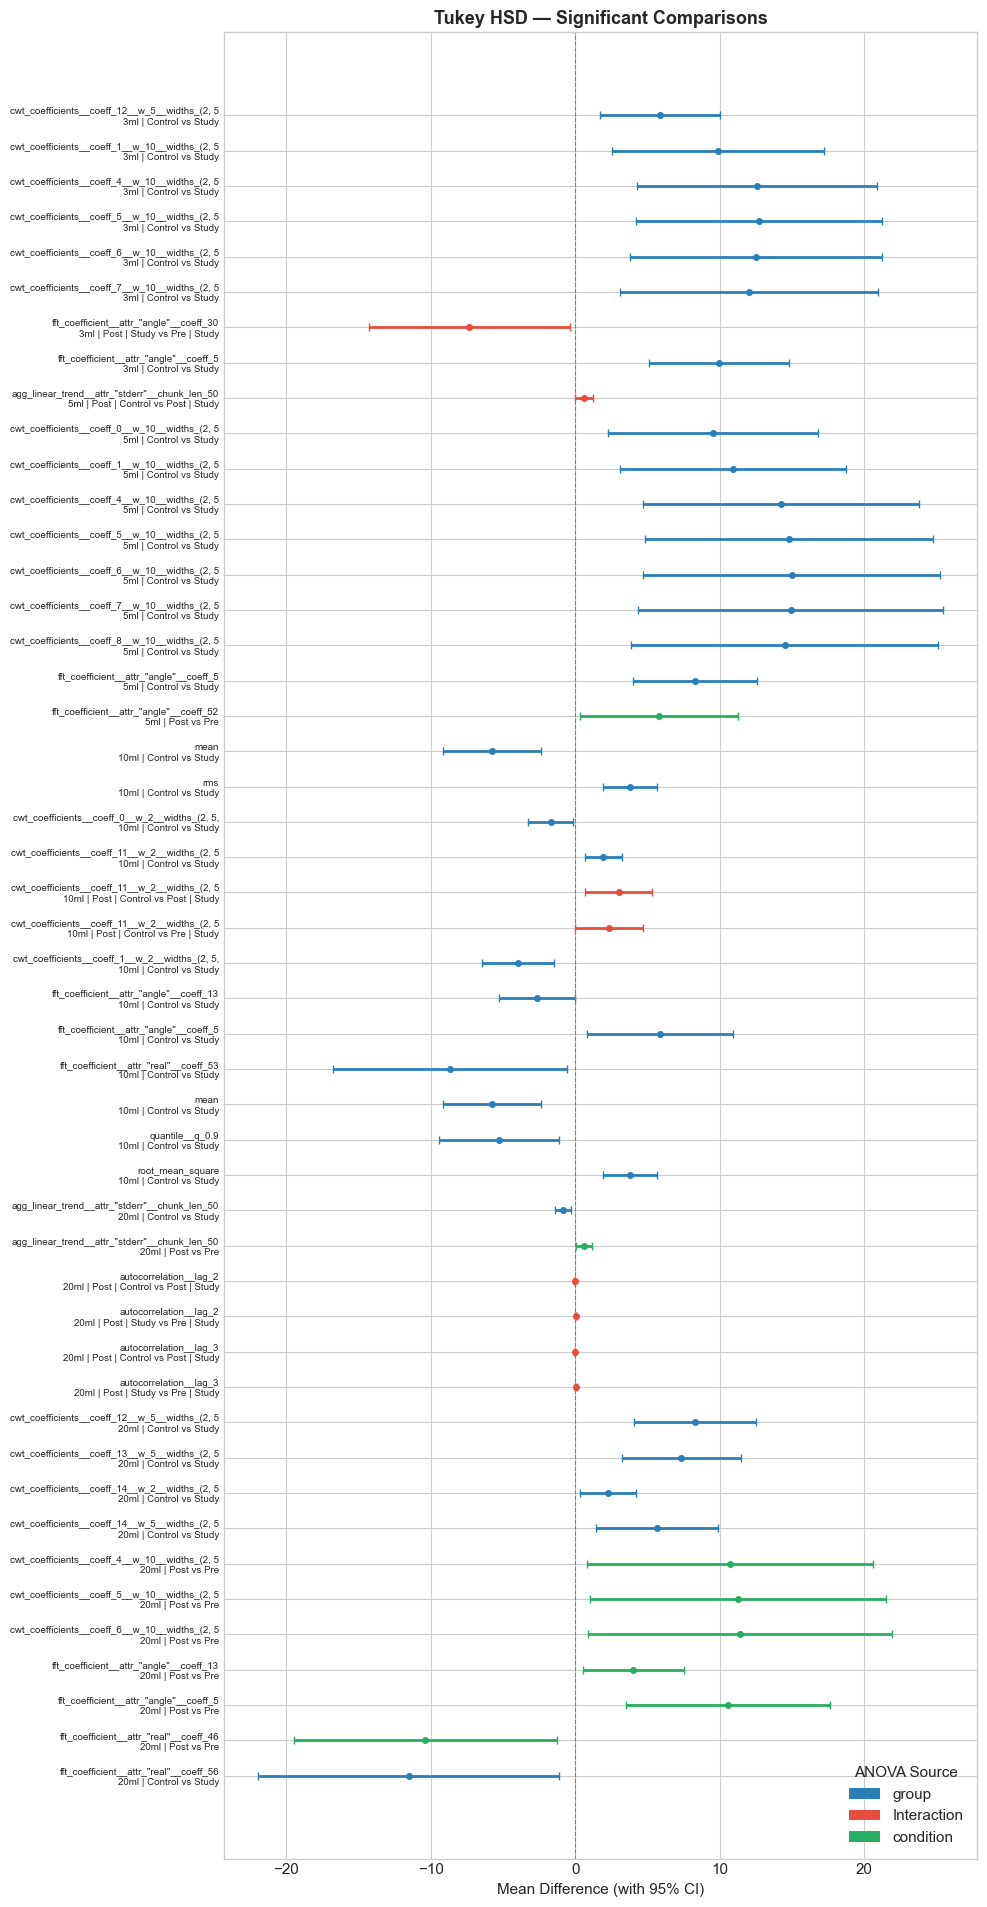

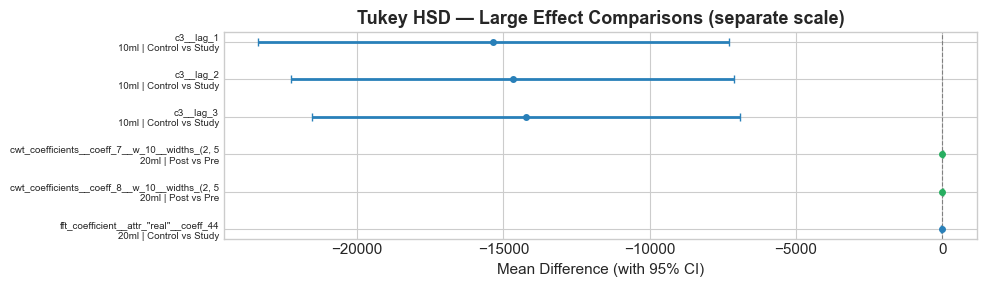

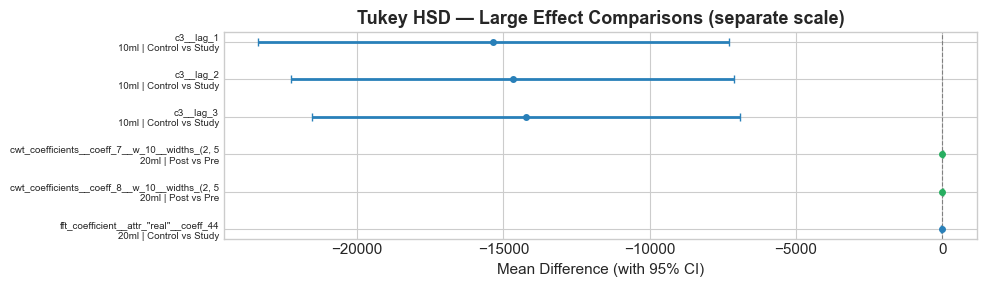

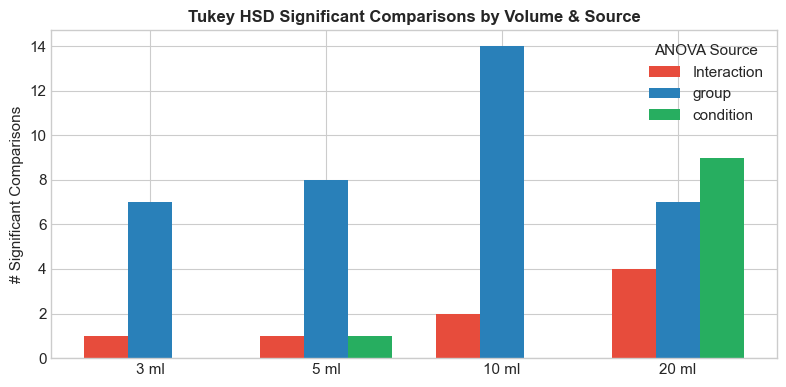

In [28]:
# --- Improved Visualizations ---
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_tukey_sig.copy()
df_plot['Short'] = df_plot['Feature'].str.replace('tsfresh_', '', regex=False).str[:45]
df_plot['Label'] = df_plot['Short'] + '\n' + df_plot['Volume (ml)'].astype(str) + 'ml | ' + df_plot['Group A'].astype(str) + ' vs ' + df_plot['Group B'].astype(str)

# Split into normal and outlier based on CI range
ci_range = (df_plot['Upper CI'] - df_plot['Lower CI']).abs()
threshold = ci_range.quantile(0.90)
df_normal = df_plot[ci_range <= threshold]
df_outlier = df_plot[ci_range > threshold]

color_map = {'group': '#2980b9', 'Interaction': '#e74c3c', 'condition': '#27ae60'}

# --- Plot 1: Main forest plot (without outliers) ---
fig, ax = plt.subplots(figsize=(10, max(6, len(df_normal) * 0.4)))
color_map = {'group': '#2980b9', 'Interaction': '#e74c3c', 'condition': '#27ae60'}

for i, (_, r) in enumerate(df_normal.iterrows()):
    c = color_map.get(r['ANOVA Source'], '#95a5a6')
    ax.errorbar(r['Mean Diff'], i,
                xerr=[[r['Mean Diff'] - r['Lower CI']], [r['Upper CI'] - r['Mean Diff']]],
                fmt='o', color=c, ecolor=c, elinewidth=2, capsize=3, markersize=4)

ax.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
ax.set_yticks(range(len(df_normal)))
ax.set_yticklabels(df_normal['Label'], fontsize=7)
ax.set_xlabel('Mean Difference (with 95% CI)')
ax.set_title('Tukey HSD — Significant Comparisons', fontsize=13, fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
used = df_normal['ANOVA Source'].unique()
ax.legend(handles=[Patch(facecolor=color_map[s], label=s) for s in used],
          title='ANOVA Source', loc='lower right')
plt.tight_layout()
plt.show()

# --- Plot 2: Outliers separately ---
if len(df_outlier) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(df_outlier) * 0.5)))
    for i, (_, r) in enumerate(df_outlier.iterrows()):
        c = color_map.get(r['ANOVA Source'], '#95a5a6')
        ax.errorbar(r['Mean Diff'], i,
                    xerr=[[r['Mean Diff'] - r['Lower CI']], [r['Upper CI'] - r['Mean Diff']]],
                    fmt='o', color=c, ecolor=c, elinewidth=2, capsize=3, markersize=4)
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_yticks(range(len(df_outlier)))
    ax.set_yticklabels(df_outlier['Label'].values, fontsize=7)
    ax.set_xlabel('Mean Difference (with 95% CI)')
    ax.set_title('Tukey HSD — Large Effect Comparisons (separate scale)', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Plot 2: Outliers separately ---
if len(df_outlier) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(df_outlier) * 0.5)))
    for i, (_, r) in enumerate(df_outlier.iterrows()):
        c = color_map.get(r['ANOVA Source'], '#95a5a6')
        ax.errorbar(r['Mean Diff'], i,
                    xerr=[[r['Mean Diff'] - r['Lower CI']], [r['Upper CI'] - r['Mean Diff']]],
                    fmt='o', color=c, ecolor=c, elinewidth=2, capsize=3, markersize=4)
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_yticks(range(len(df_outlier)))
    ax.set_yticklabels(df_outlier['Label'].values, fontsize=7)
    ax.set_xlabel('Mean Difference (with 95% CI)')
    ax.set_title('Tukey HSD — Large Effect Comparisons (separate scale)', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Plot 3: Grouped bar by volume (unchanged, already looks good) ---
summary = df_tukey_sig.groupby(['Volume (ml)', 'ANOVA Source']).size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(8, 4))
vols = sorted(summary['Volume (ml)'].unique())
sources = summary['ANOVA Source'].unique()
x = np.arange(len(vols))
width = 0.25
for i, src in enumerate(sources):
    counts = [summary[(summary['Volume (ml)'] == v) & (summary['ANOVA Source'] == src)]['Count'].sum()
              if len(summary[(summary['Volume (ml)'] == v) & (summary['ANOVA Source'] == src)]) > 0 else 0
              for v in vols]
    ax.bar(x + i * width, counts, width, label=src, color=color_map.get(src, '#95a5a6'))
ax.set_xticks(x + width * (len(sources) - 1) / 2)
ax.set_xticklabels([f'{int(v)} ml' for v in vols])
ax.set_ylabel('# Significant Comparisons')
ax.set_title('Tukey HSD Significant Comparisons by Volume & Source', fontsize=12, fontweight='bold')
ax.legend(title='ANOVA Source')
plt.tight_layout()
plt.show()

#### Simple effect ('Dimensão do efeito')

Simple effects: 17 significant out of 40 total



Volume (ml),Feature,Test,Group A,Group B,Mean A,Mean B,Mean Diff,t,df,p,Cohen d,d label,ηp²,ηp² label,Sig
3,tsfresh_approximate_entropy__m_2__r_0.1,Group effect at Post,Control,Study,0.4116,0.3312,0.0804,2.3613,21,0.0280,1.0088,Very large,0.2098,Medium,*
3,tsfresh_approximate_entropy__m_2__r_0.1,Group effect at Pre,Control,Study,0.3507,0.3813,-0.0305,-1.1040,21,0.2821,-0.4717,Medium,0.0549,Medium,
3,tsfresh_approximate_entropy__m_2__r_0.1,Condition effect in Control,Post,Pre,0.4116,0.3507,0.0608,2.4697,13,0.0281,-0.6601,Large,0.3194,Large,*
3,tsfresh_approximate_entropy__m_2__r_0.1,Condition effect in Study,Post,Pre,0.3312,0.3813,-0.0500,-1.2150,8,0.2590,0.4050,Medium,0.1558,Medium,
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Group effect at Post,Control,Study,-70.0108,-64.2436,-5.7672,-2.2851,21,0.0328,-0.9763,Large,0.1991,Medium,*
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Group effect at Pre,Control,Study,-67.8992,-71.5873,3.6881,1.6918,21,0.1055,0.7228,Large,0.1199,Medium,
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Condition effect in Control,Post,Pre,-70.0108,-67.8992,-2.1116,-0.8951,13,0.3870,0.2392,Medium,0.0580,Medium,
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Condition effect in Study,Post,Pre,-64.2436,-71.5873,7.3437,3.6346,8,0.0066,-1.2115,Very large,0.6228,Very large,**
5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Group effect at Post,Control,Study,3.4539,4.0876,-0.6337,-2.4901,21,0.0212,-1.0639,Very large,0.2280,Medium,*
5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Group effect at Pre,Control,Study,3.9452,3.4830,0.4622,2.1854,21,0.0403,0.9337,Large,0.1853,Medium,*



EFFECT SIZE SUMMARY — Significant simple effects only



,Volume (ml),Feature,Test,Cohen d,d label,ηp²,ηp² label,p
0,3,tsfresh_approximate_entropy__m_2__r_0.1,Group effect at Post,1.008800,Very large,0.209800,Medium,0.028000
2,3,tsfresh_approximate_entropy__m_2__r_0.1,Condition effect in Control,-0.660100,Large,0.319400,Large,0.028100
4,3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Group effect at Post,-0.976300,Large,0.199100,Medium,0.032800
7,3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Condition effect in Study,-1.211500,Very large,0.622800,Very large,0.006600
8,5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Group effect at Post,-1.063900,Very large,0.228000,Medium,0.021200
9,5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Group effect at Pre,0.933700,Large,0.185300,Medium,0.040300
10,5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Condition effect in Control,0.817600,Large,0.418600,Large,0.009100
11,5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Condition effect in Study,-0.931500,Large,0.494000,Large,0.023400
12,5,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Group effect at Post,-1.396500,Very large,0.337200,Large,0.003700
19,5,"tsfresh_fft_coefficient__attr_""angle""__coeff_60",Condition effect in Study,0.855400,Large,0.451500,Large,0.033300


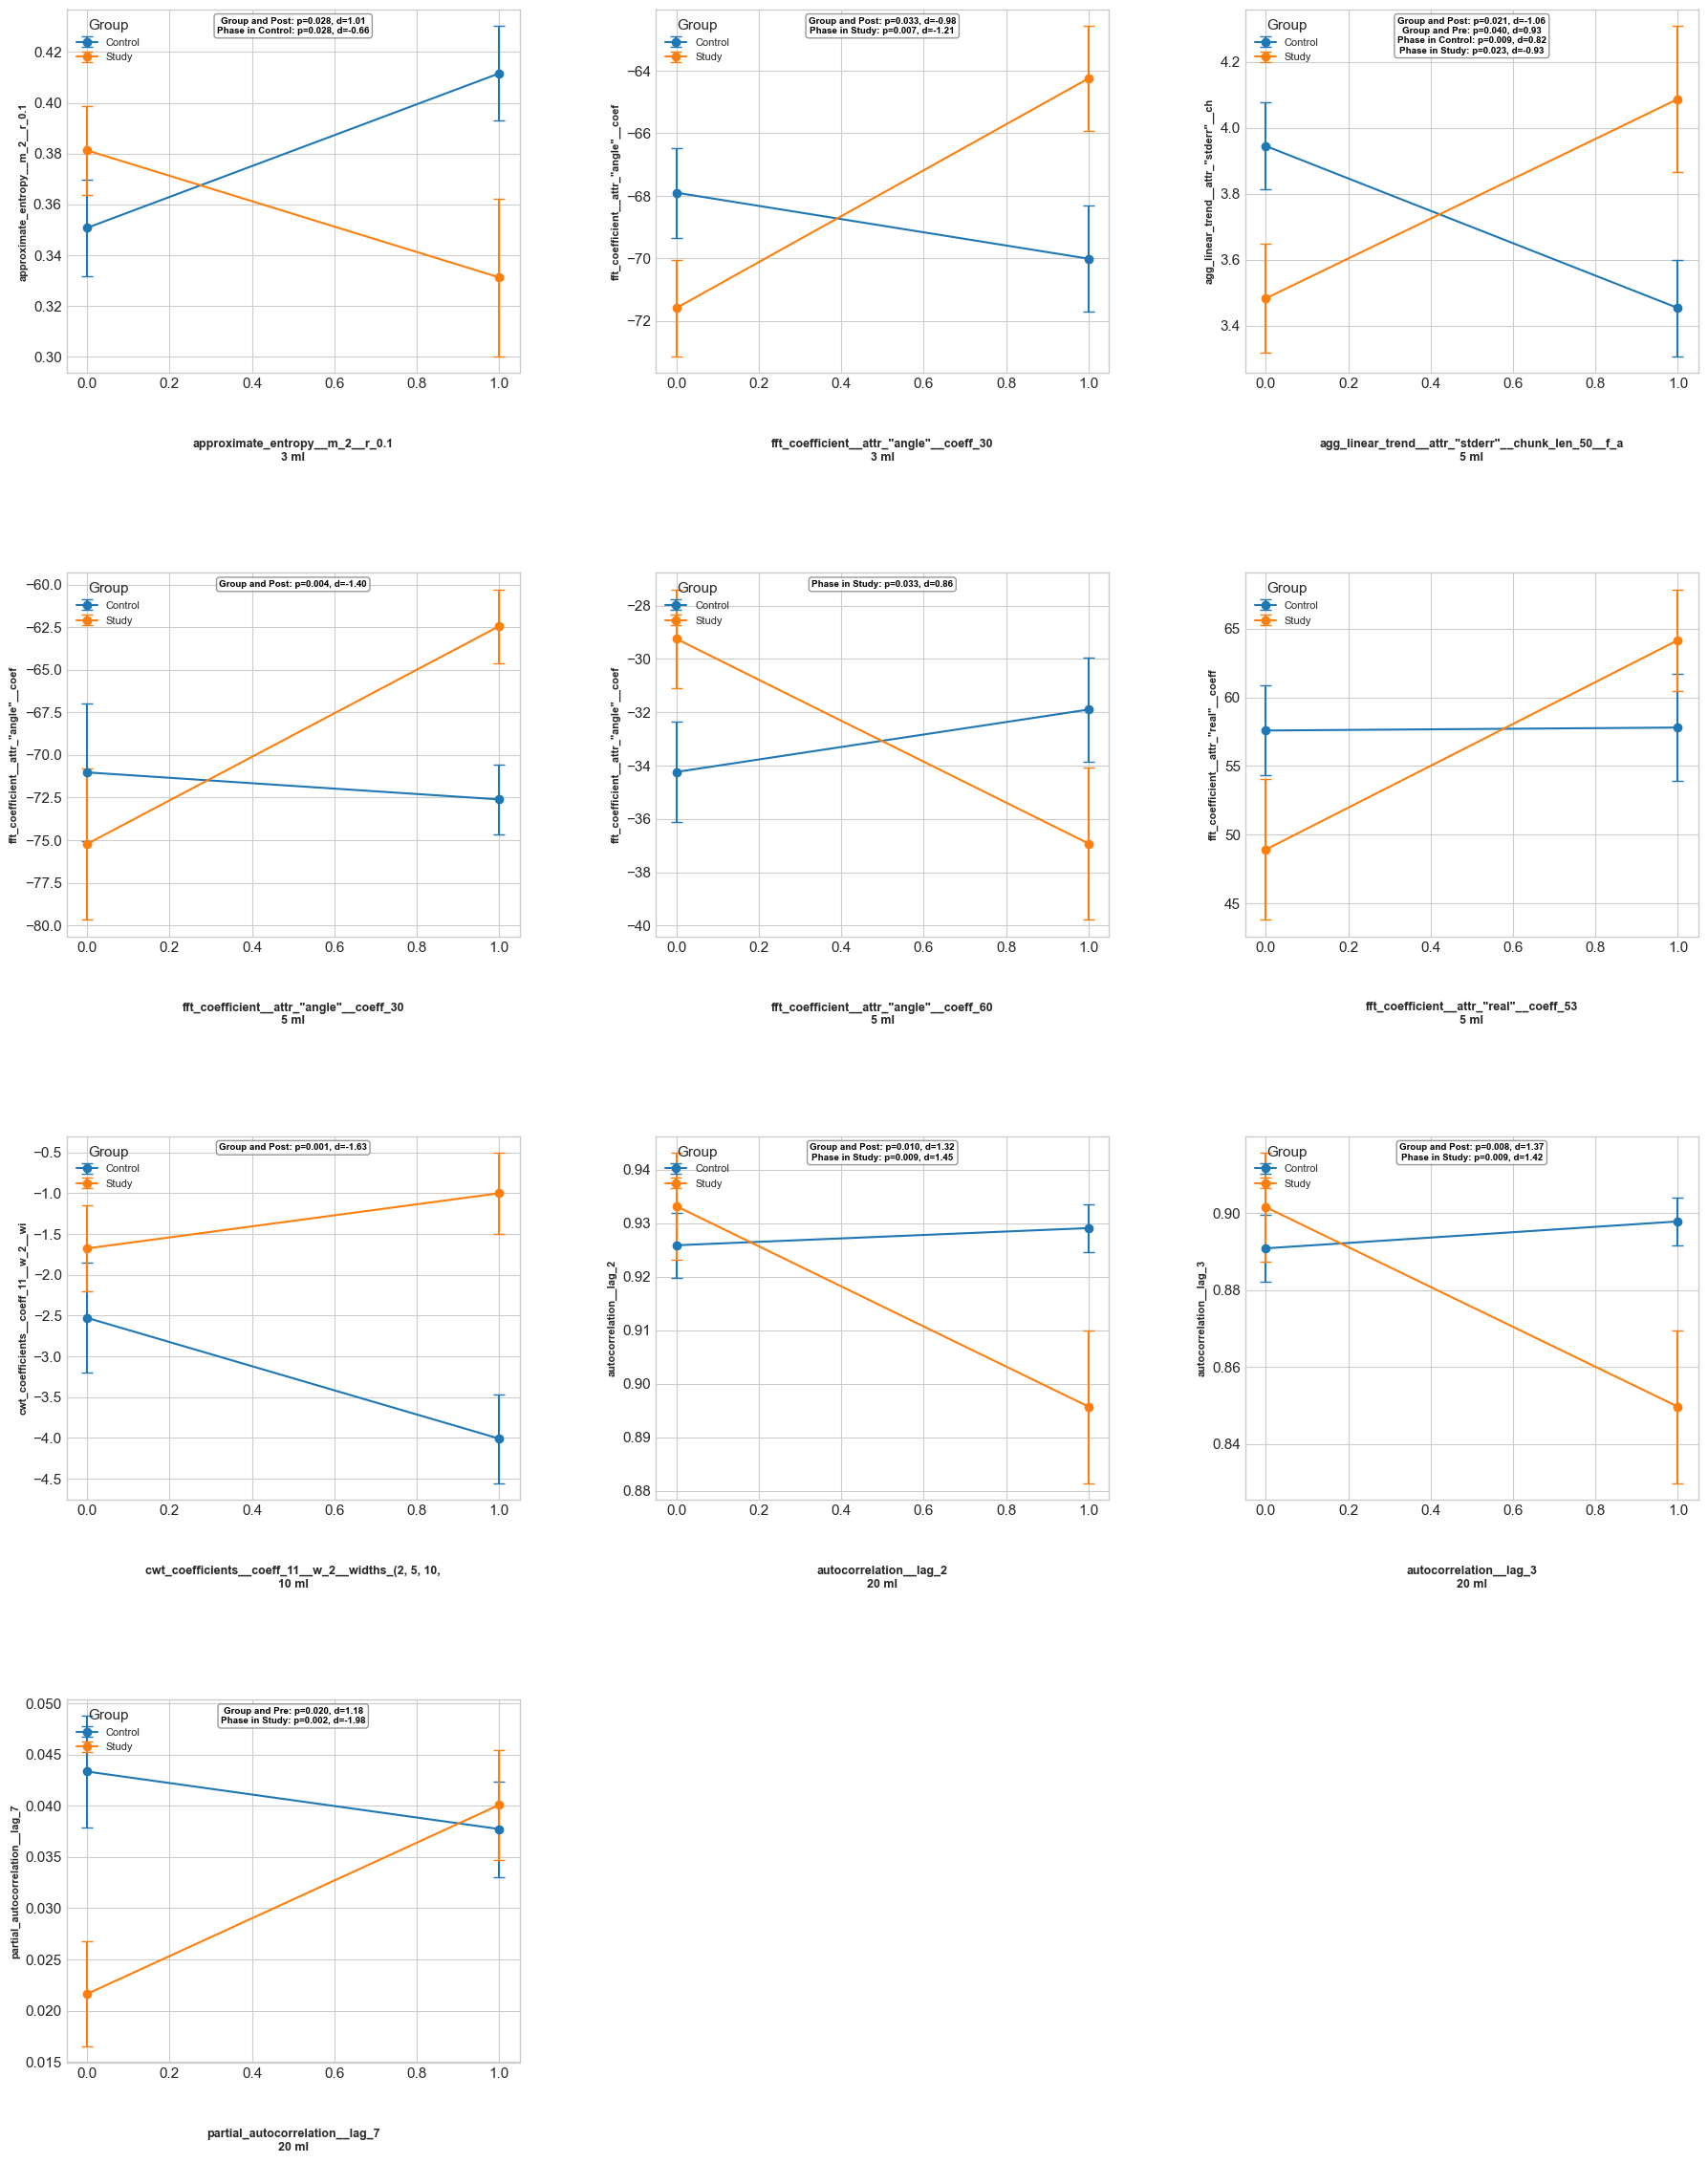

In [37]:
df_sig_anova = df_anova[df_anova['Significant'] == '✓'].copy()
sig_interactions = df_sig_anova[df_sig_anova['Source'].str.contains('nteraction|\\*', regex=True)]

simple_results = []

# --- Effect size helpers ---
def cohens_d_independent(g1, g2):
    """Cohen's d for independent samples (pooled SD)."""
    n1, n2 = len(g1), len(g2)
    pooled_sd = np.sqrt(((n1 - 1) * g1.std(ddof=1)**2 + (n2 - 1) * g2.std(ddof=1)**2) / (n1 + n2 - 2))
    if pooled_sd == 0:
        return np.nan
    return (g1.mean() - g2.mean()) / pooled_sd

def cohens_d_paired(pre, post):
    """Cohen's d for paired samples (SD of differences)."""
    diff = post - pre
    sd_diff = diff.std(ddof=1)
    if sd_diff == 0:
        return np.nan
    return diff.mean() / sd_diff

def effect_label_d(d):
    """Classify |d| following Cohen (1988) — book table."""
    d = abs(d)
    if d > 1.0:
        return 'Very large'
    elif d > 0.5:
        return 'Large'
    elif d > 0.2:
        return 'Medium'
    else:
        return 'Small'

def eta2p_from_t(t, df_val):
    """Partial eta-squared from t and df:  η²p = t² / (t² + df)."""
    return t**2 / (t**2 + df_val)

def effect_label_eta2p(eta):
    """Classify η²p following Cohen (1988) — book table."""
    if eta > 0.50:
        return 'Very large'
    elif eta > 0.25:
        return 'Large'
    elif eta > 0.05:
        return 'Medium'
    else:
        return 'Small'


for _, row in sig_interactions.iterrows():
    vol, feat = row['Volume (ml)'], row['Feature']
    df_vol = df[df['volume_ml'] == vol].copy()

    # 1) Simple effect of GROUP at each condition level (between-subjects)
    for cond in sorted(df_vol['condition'].unique()):
        subset = df_vol[df_vol['condition'] == cond]
        groups_data = [subset[subset['group'] == g][feat].dropna() for g in sorted(subset['group'].unique())]
        if all(len(g) >= 3 for g in groups_data):
            from scipy.stats import ttest_ind
            t_stat, p_val = ttest_ind(groups_data[0], groups_data[1])
            d = cohens_d_independent(groups_data[0], groups_data[1])
            df_t = len(groups_data[0]) + len(groups_data[1]) - 2
            eta2p = eta2p_from_t(t_stat, df_t)
            simple_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'Test': f'Group effect at {cond}',
                'Group A': sorted(subset['group'].unique())[0],
                'Group B': sorted(subset['group'].unique())[1],
                'Mean A': round(groups_data[0].mean(), 4),
                'Mean B': round(groups_data[1].mean(), 4),
                'Mean Diff': round(groups_data[0].mean() - groups_data[1].mean(), 4),
                't': round(t_stat, 4),
                'df': df_t,
                'p': round(p_val, 4),
                'Cohen d': round(d, 4),
                'd label': effect_label_d(d),
                'ηp²': round(eta2p, 4),
                'ηp² label': effect_label_eta2p(eta2p),
            })

    # 2) Simple effect of CONDITION at each group level (within-subjects)
    for grp in sorted(df_vol['group'].unique()):
        subset = df_vol[df_vol['group'] == grp]
        cond_levels = sorted(subset['condition'].unique())
        if len(cond_levels) == 2:
            pre = subset[subset['condition'] == cond_levels[0]].set_index('subject')[feat].dropna()
            post = subset[subset['condition'] == cond_levels[1]].set_index('subject')[feat].dropna()
            common = pre.index.intersection(post.index)
            if len(common) >= 3:
                from scipy.stats import ttest_rel
                t_stat, p_val = ttest_rel(pre.loc[common], post.loc[common])
                d = cohens_d_paired(pre.loc[common].values, post.loc[common].values)
                df_t = len(common) - 1
                eta2p = eta2p_from_t(t_stat, df_t)
                simple_results.append({
                    'Volume (ml)': int(vol),
                    'Feature': feat,
                    'Test': f'Condition effect in {grp}',
                    'Group A': cond_levels[0],
                    'Group B': cond_levels[1],
                    'Mean A': round(pre.loc[common].mean(), 4),
                    'Mean B': round(post.loc[common].mean(), 4),
                    'Mean Diff': round(pre.loc[common].mean() - post.loc[common].mean(), 4),
                    't': round(t_stat, 4),
                    'df': df_t,
                    'p': round(p_val, 4),
                    'Cohen d': round(d, 4),
                    'd label': effect_label_d(d),
                    'ηp²': round(eta2p, 4),
                    'ηp² label': effect_label_eta2p(eta2p),
                })

df_simple = pd.DataFrame(simple_results)

# Significance at α = 0.05 (no multiple-comparison correction)
df_simple['Sig'] = df_simple['p'].apply(
    lambda p: '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
)

# --- Display ---
df_simple_sig = df_simple[df_simple['p'] < 0.05]
print(f"Simple effects: {len(df_simple_sig)} significant out of {len(df_simple)} total\n")

html = df_simple.to_html(index=False)
display(HTML(f"""
<div style="max-height: 600px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
    <h3>Simple Effects Analysis (Significant Interactions Only)</h3>
    {html}
</div>
"""))

# --- Effect size summary ---
if not df_simple_sig.empty:
    print(f"\n{'='*80}")
    print("EFFECT SIZE SUMMARY — Significant simple effects only")
    print(f"{'='*80}\n")
    es_summary = df_simple_sig[['Volume (ml)', 'Feature', 'Test', 'Cohen d', 'd label', 'ηp²', 'ηp² label', 'p']].copy()
    es_summary = es_summary.sort_values(['Volume (ml)', 'Feature'])
    display(es_summary.style
        .applymap(lambda v: 'background-color: #2d5f2d; color: white' if v in ['Large', 'Very large'] else '',
                  subset=['d label', 'ηp² label'])
        .set_properties(**{'font-size': '10px', 'text-align': 'center'})
    )

# --- Interaction plots with simple effects + effect size annotations ---
if len(sig_interactions) > 0:
    cond_levels = ['Pre', 'Post']
    group_levels = sorted(df['group'].unique())
    colors = {g: c for g, c in zip(group_levels, ['#1f77b4', '#ff7f0e'])}

    n = len(sig_interactions)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)

    for idx, (_, r) in enumerate(sig_interactions.iterrows()):
        ax = axes[idx // ncols][idx % ncols]
        vol, feat = r['Volume (ml)'], r['Feature']
        df_vol = df[df['volume_ml'] == vol]

        for g in group_levels:
            means = [df_vol[(df_vol['condition'] == c) & (df_vol['group'] == g)][feat].mean() for c in cond_levels]
            sems = [df_vol[(df_vol['condition'] == c) & (df_vol['group'] == g)][feat].sem() for c in cond_levels]
            ax.errorbar(range(len(cond_levels)), means, yerr=sems,
                        marker='o', label=g, color=colors[g], capsize=4)

        # Collect significant simple effects text
        feat_simple = df_simple[(df_simple['Feature'] == feat) & (df_simple['Volume (ml)'] == vol)]
        sig_labels = []
        for _, s in feat_simple.iterrows():
            if s['p'] < 0.05:
                if 'Group effect' in s['Test']:
                    phase = s['Test'].split('at ')[-1]
                    sig_labels.append(f"Group and {phase}: p={s['p']:.3f}, d={s['Cohen d']:.2f}")
                elif 'Condition effect' in s['Test']:
                    grp_name = s['Test'].split('in ')[-1]
                    sig_labels.append(f"Phase in {grp_name}: p={s['p']:.3f}, d={s['Cohen d']:.2f}")

        # Legend + significant effects
        legend = ax.legend(title='Group', fontsize=8, loc='upper left')
        if sig_labels:
            sig_text = '\n'.join(sig_labels)
            ax.text(0.5, 0.98, sig_text, transform=ax.transAxes,
                    fontsize=7, fontweight='bold', color='black',
                    ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

        ax.set_ylabel(feat.replace('tsfresh_', '')[:35], fontsize=8, fontweight='bold')

        # Title below the plot
        ax.set_title('')  # clear top title
        ax.text(0.5, -0.18, f"{feat.replace('tsfresh_', '')[:50]}\n{int(vol)} ml",
                transform=ax.transAxes, fontsize=9, ha='center', va='top', fontweight='bold')

    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.subplots_adjust(hspace=0.55, wspace=0.3)
    plt.show()

### Non-Parametric tests (Wilcoxon, Friedman, Mann-Whintey)

In [30]:
from scipy.stats import friedmanchisquare, wilcoxon, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

friedman_results = []
wilcoxon_results = []
mannwhitney_results = []

for feat in nonparametric_features:

    # --- FRIEDMAN: across volumes, per group × condition ---
    for g in groups:
        for cond in conditions:
            vol_data = []
            for vol in volumes:
                d = df[(df['volume_ml'] == vol) & (df['group'] == g) & (df['condition'] == cond)][feat].dropna()
                vol_data.append(d.values)
            # Friedman needs equal-length arrays (same subjects across volumes)
            min_len = min(len(d) for d in vol_data)
            if min_len >= 3 and len(vol_data) >= 3:
                vol_data_trimmed = [d[:min_len] for d in vol_data]
                try:
                    stat, p = friedmanchisquare(*vol_data_trimmed)
                    friedman_results.append({
                        'Feature': feat,
                        'Group': g,
                        'Condition': cond,
                        'Statistic': round(stat, 4),
                        'p-value': round(p, 4),
                        'Significant': '✓' if p < 0.05 else '',
                    })
                except Exception:
                    pass

    # --- WILCOXON: pre vs pos, per group × volume ---
    for g in groups:
        for vol in volumes:
            df_sub = df[(df['volume_ml'] == vol) & (df['group'] == g)]
            pre = df_sub[df_sub['condition'] == conditions[0]][feat].dropna().values
            pos = df_sub[df_sub['condition'] == conditions[1]][feat].dropna().values
            min_len = min(len(pre), len(pos))
            if min_len >= 3:
                try:
                    stat, p = wilcoxon(pre[:min_len], pos[:min_len])
                    wilcoxon_results.append({
                        'Feature': feat,
                        'Group': g,
                        'Volume (ml)': int(vol),
                        'Statistic': round(stat, 4),
                        'p-value': round(p, 4),
                        'Significant': '✓' if p < 0.05 else '',
                    })
                except Exception:
                    pass

    # --- MANN-WHITNEY: between groups, per volume × condition ---
    for vol in volumes:
        for cond in conditions:
            g1 = df[(df['volume_ml'] == vol) & (df['condition'] == cond) & (df['group'] == groups[0])][feat].dropna().values
            g2 = df[(df['volume_ml'] == vol) & (df['condition'] == cond) & (df['group'] == groups[1])][feat].dropna().values
            if len(g1) >= 2 and len(g2) >= 2:
                stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
                mannwhitney_results.append({
                    'Feature': feat,
                    'Volume (ml)': int(vol),
                    'Condition': cond,
                    'Statistic': round(stat, 4),
                    'p-value': round(p, 4),
                    'Significant': '✓' if p < 0.05 else '',
                })

# Display all three tables
from IPython.display import display, HTML

for name, results in [('FRIEDMAN (across volumes)', friedman_results),
                       ('WILCOXON (pre vs pos)', wilcoxon_results),
                       ('MANN-WHITNEY (between groups)', mannwhitney_results)]:
    df_res = pd.DataFrame(results)
    html = df_res.to_html(index=False)
    display(HTML(f"""
    <h3>{name}</h3>
    <div style="max-height: 400px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
        {html}
    </div>
    """))
    n_sig = len(df_res[df_res['Significant'] == '✓']) if len(df_res) > 0 else 0
    print(f"  → {n_sig} significant results out of {len(df_res)}\n")

Feature,Group,Condition,Statistic,p-value,Significant
energy,Control,Post,7.4571,0.0587,
energy,Control,Pre,9.2571,0.0261,✓
energy,Study,Post,1.4571,0.6922,
energy,Study,Pre,6.4286,0.0925,
iqr,Control,Post,4.0286,0.2584,
iqr,Control,Pre,2.2286,0.5263,
iqr,Study,Post,7.6286,0.0543,
iqr,Study,Pre,3.0000,0.3916,
kurtosis,Control,Post,4.7143,0.1940,
kurtosis,Control,Pre,1.1143,0.7736,


  → 131 significant results out of 2628



Feature,Group,Volume (ml),Statistic,p-value,Significant
energy,Control,3,34.0,0.2676,
energy,Control,5,45.0,0.6698,
energy,Control,10,30.0,0.1726,
energy,Control,20,39.0,0.4263,
energy,Study,3,12.0,0.2500,
energy,Study,5,18.0,0.6523,
energy,Study,10,21.0,0.9102,
energy,Study,20,11.0,0.6875,
iqr,Control,3,46.0,0.7148,
iqr,Control,5,47.0,0.7609,


  → 507 significant results out of 5256



Feature,Volume (ml),Condition,Statistic,p-value,Significant
energy,3,Post,28.0,0.0298,✓
energy,3,Pre,45.0,0.2703,
energy,5,Post,47.0,0.3289,
energy,5,Pre,44.0,0.2439,
energy,10,Post,31.0,0.0472,✓
energy,10,Pre,35.0,0.0832,
energy,20,Post,34.0,0.2872,
energy,20,Pre,26.0,0.0938,
iqr,3,Post,43.0,0.2193,
iqr,3,Pre,67.0,0.8255,


  → 291 significant results out of 5256



### Significant features results:

In [31]:
df_friedman = pd.DataFrame(friedman_results)
df_wilcoxon = pd.DataFrame(wilcoxon_results)
df_mannwhitney = pd.DataFrame(mannwhitney_results)

df_friedman_sig = df_friedman[df_friedman['Significant'] == '✓'].copy()
df_wilcoxon_sig = df_wilcoxon[df_wilcoxon['Significant'] == '✓'].copy()
df_mannwhitney_sig = df_mannwhitney[df_mannwhitney['Significant'] == '✓'].copy()

from IPython.display import display, HTML

for name, df_sig in [('FRIEDMAN – Significant', df_friedman_sig),
                      ('WILCOXON – Significant', df_wilcoxon_sig),
                      ('MANN-WHITNEY – Significant', df_mannwhitney_sig)]:
    html = df_sig.to_html(index=False)
    display(HTML(f"""
    <h3>{name}</h3>
    <div style="max-height: 400px; overflow-y: auto; border: 1px solid #ccc; padding: 4px;">
        {html}
    </div>
    """))
    sig_feats = sorted(df_sig['Feature'].unique()) if len(df_sig) > 0 else []
    print(f"  → {len(df_sig)} significant results across {len(sig_feats)} features: {sig_feats}\n")

# Store for downstream use
sig_friedman_features = sorted(df_friedman_sig['Feature'].unique()) if len(df_friedman_sig) > 0 else []
sig_wilcoxon_features = sorted(df_wilcoxon_sig['Feature'].unique()) if len(df_wilcoxon_sig) > 0 else []
sig_mannwhitney_features = sorted(df_mannwhitney_sig['Feature'].unique()) if len(df_mannwhitney_sig) > 0 else []

Feature,Group,Condition,Statistic,p-value,Significant
energy,Control,Pre,9.2571,0.0261,✓
max,Control,Post,9.3429,0.0251,✓
std,Control,Post,9.8571,0.0198,✓
std,Study,Post,10.3714,0.0157,✓
tsfresh_abs_energy,Control,Pre,9.2571,0.0261,✓
"tsfresh_agg_autocorrelation__f_agg_""mean""__maxlag_40",Control,Post,9.6857,0.0214,✓
"tsfresh_agg_autocorrelation__f_agg_""var""__maxlag_40",Control,Post,10.2000,0.0169,✓
"tsfresh_agg_autocorrelation__f_agg_""var""__maxlag_40",Study,Post,9.1714,0.0271,✓
"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_50__f_agg_""min""",Control,Pre,8.4000,0.0384,✓
"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_50__f_agg_""var""",Study,Post,7.9714,0.0466,✓


  → 131 significant results across 117 features: ['energy', 'max', 'std', 'tsfresh_abs_energy', 'tsfresh_agg_autocorrelation__f_agg_"mean"__maxlag_40', 'tsfresh_agg_autocorrelation__f_agg_"var"__maxlag_40', 'tsfresh_agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"var"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_10__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_10__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_10__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_50__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_5__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_5__f_agg_"mean"', 'tsfresh_agg_linear_t

Feature,Group,Volume (ml),Statistic,p-value,Significant
kurtosis,Study,20,2.0,0.0469,✓
std,Study,20,0.0,0.0156,✓
tsfresh_absolute_sum_of_changes,Control,3,3.0,0.0006,✓
"tsfresh_agg_autocorrelation__f_agg_""mean""__maxlag_40",Study,20,2.0,0.0469,✓
"tsfresh_agg_autocorrelation__f_agg_""median""__maxlag_40",Study,20,2.0,0.0469,✓
"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_5__f_agg_""var""",Control,20,21.0,0.0494,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""max""",Study,20,2.0,0.0469,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""mean""",Study,20,1.0,0.0312,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""min""",Study,20,0.0,0.0156,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""var""",Control,20,15.0,0.0166,✓


  → 507 significant results across 269 features: ['kurtosis', 'std', 'tsfresh_absolute_sum_of_changes', 'tsfresh_agg_autocorrelation__f_agg_"mean"__maxlag_40', 'tsfresh_agg_autocorrelation__f_agg_"median"__maxlag_40', 'tsfresh_agg_linear_trend__attr_"intercept"__chunk_len_5__f_agg_"var"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"var"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_50__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_50__f_agg_"var"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"var"', 'tsfresh_agg

Feature,Volume (ml),Condition,Statistic,p-value,Significant
energy,3,Post,28.0,0.0298,✓
energy,10,Post,31.0,0.0472,✓
iqr,20,Post,78.0,0.0309,✓
kurtosis,20,Post,17.0,0.0159,✓
median,10,Post,101.0,0.0182,✓
min,10,Post,96.0,0.0406,✓
std,20,Post,87.0,0.0031,✓
tsfresh_abs_energy,3,Post,28.0,0.0298,✓
tsfresh_abs_energy,10,Post,31.0,0.0472,✓
tsfresh_absolute_maximum,10,Post,30.0,0.0406,✓


  → 291 significant results across 220 features: ['energy', 'iqr', 'kurtosis', 'median', 'min', 'std', 'tsfresh_abs_energy', 'tsfresh_absolute_maximum', 'tsfresh_absolute_sum_of_changes', 'tsfresh_agg_autocorrelation__f_agg_"var"__maxlag_40', 'tsfresh_agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"var"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_50__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"rvalue"__chunk_len_5__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_10__f_agg_"max"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_10__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"slope"__chunk_len_10__f